# Decoded Can Data Classification by ID

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

import warnings
warnings.filterwarnings(action='ignore')

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

dir_name = ''
# 저장할 경로 설정 (예: 'My Drive/filtered_data')
# save_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data'
device = ('cuda' if torch.cuda.is_available() else 'cpu')

# CAN Message Decode

In [ ]:
pip install cantools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.2/265.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.4 MB/s eta 0:00:00


In [ ]:
import can
import cantools
from pprint import pprint

db = cantools.database.load_file('drive/MyDrive/Colab Notebooks/CAN_IDS/hyundai_kia_generic_modi.dbc')

dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
# 저장할 경로 설정 (예: 'My Drive/filtered_data')
save_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data'

attacks_map0 ={'Normal': 0, 'Fuzzing': 1, 'Replay': 1, 'Spoofing': 1, 'Flooding': 1}
attacks_map1 ={'Normal': 0, 'Fuzzing': 1, 'Replay': 2, 'Spoofing': 3, 'Flooding': 4}

def decode_can_message(row):
    try:
        decoded_message = db.decode_message(row['Hex_ID'], row['Hex_Data'])
        return decoded_message
    except Exception as e:
        return str(e)

for i in range(3):
  data_file_name = f'Pre_train_D_{i}'
  # decoded_file_name = f'{dir_name}{data_file_name}_ID_{arb_id}.csv'
  can_normal = pd.read_csv(f'{dir_name}{data_file_name}.csv')
  #can_normal = pd.read_csv('drive/MyDrive/Colab Notebooks/CAN_IDS/Pre_train_D_0.csv')
  data_columns = ['D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']
  can_normal[data_columns[:8]] = can_normal['Data'].str.split(expand=True).iloc[:, :8]
  for col in data_columns:
    can_normal[col] = can_normal[col].fillna('00')
    can_normal[col] = can_normal[col].apply(int,base=16)

  can_normal['Hex_ID'] = can_normal['Arbitration_ID'][:].apply(int,base=16)
  can_normal['Hex_Data'] = can_normal['Data'][:].apply(bytes.fromhex)
  can_normal['Decoded'] = can_normal.apply(decode_can_message, axis=1)

  # Attack에 대해 integer mapping
  if i == 0:
    can_normal["SubClass"] = can_normal["Class"]
    can_normal["Class0"] = can_normal["Class"].map(attacks_map0)
    can_normal["Class1"] = can_normal["Class"].map(attacks_map0)
  else:
    can_normal["Class0"] = can_normal["SubClass"].map(attacks_map0)
    can_normal["Class1"] = can_normal["SubClass"].map(attacks_map1)

  # Unique Arbitration_ID 리스트 생성
  unique_ids = can_normal['Arbitration_ID'].unique()

  saved_file_count = 0  # 저장된 파일의 개수를 세기 위한 변수
  no_decoded_count = 0  # 분석되지 않은 ID의 개수를 세기 위한 변수
  no_decoded_ids = []  # 분석되지 않은 ID를 저장할 리스트

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for arb_id in unique_ids:
      select_db = can_normal[can_normal['Arbitration_ID'] == arb_id]

      # decoded_message_example = {
      #     'TQI_MIN': 2.34375,
      #     'TQI': 14.453125,
      #     'TQI_TARGET': 1.953125,
      #     'GLOW_STAT': 0,
      #     'CRUISE_LAMP_M': 0,
      #     'CRUISE_LAMP_S': 0,
      #     'PRE_FUEL_CUT_IN': 0,
      #     'ENG_STAT': 3,
      #     'SOAK_TIME_ERROR': 0,
      #     'SOAK_TIME': 255,
      #     'TQI_MAX': 80.859375,
      #     'SPK_TIME_CUR': 6.75,
      #     'Checksum': 5,
      #     'AliveCounter': 1,
      #     'CF_Ems_AclAct': 1
      # }
      decoded_message_example = select_db['Decoded'].values[0]
      # print(arb_id)
      # print(decoded_message_example)

      # 파일명 생성
      file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
      file_path = f'{save_path}/{file_name}'

      if type(decoded_message_example) is not dict:
        no_decoded_count += 1
        no_decoded_ids.append(arb_id)
        # CSV 파일로 저장
        select_db.to_csv(file_path, index=False)
        print(file_path)
        continue

      # Decoded_Message 딕셔너리를 각각의 컬럼으로 확장
      for key in decoded_message_example.keys():
          select_db.loc[:, key] = select_db['Decoded'].apply(lambda x: x.get(key) if isinstance(x, dict) else None)

      # CSV 파일로 저장
      select_db.to_csv(file_path, index=False)
      print(f'{file_name} 저장 완료')
      saved_file_count += 1

  print(f"총 {saved_file_count}개의 파일이 저장되었습니다.")
  print(f"총 {no_decoded_count}개의 ID가 분석되지 않았습니다.")
  print(f"분석되지 않은 ID 목록:   {no_decoded_ids} ")

ModuleNotFoundError: No module named 'can'

# LSTM/GRU

## Module Import

In [24]:
# !pip install "c:\Users\mariu\source\Python\CAN_IDS\tqdm-4.66.5-py3-none-any.whl"
#!pip install "tqdm-4.66.5-py3-none-any.whl"
!pip install tqdm
!pip install contextlib2 

In [64]:
#-*- coding: utf-8 -*-
# 대부분의 코드는 Baseline을 따랐으며, 수정된 부분만 주석처리하여 설명함.
import sys
from pathlib import Path
from datetime import timedelta
import dateutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import trange
#from TaPR_pkg import etapr
from contextlib2 import redirect_stdout
import random

from sklearn.metrics import confusion_matrix
#from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from numpy import linalg as LA

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

## train model save

###make normalized data

In [ ]:
# dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
# data_file_name = f'Pre_train_D_{0}'
# can_normal = pd.read_csv(f'{dir_name}{data_file_name}.csv')

# # Unique Arbitration_ID 리스트 생성
# unique_file_name = f'unique_ids{0}.csv'
# unique_ids = can_normal['Arbitration_ID'].unique()
# print(unique_ids)
# unique_ids_pd = pd.DataFrame(unique_ids)
# unique_ids_pd.columns = ['Arbitration_ID']
# unique_ids_pd.to_csv(f'{dir_name}{unique_file_name}', index=False)
# unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}')
# unique_ids_pd

# Assuming df_can is your DataFrame and it's already defined
#1그룹(10ms) '260', '153', '220', '251', '367', '366', '356', '164', '2B0', '368','340', '329', '130', '140'
#2그룹(20ms) '391', '387', '453', '4F1', '394', '470','381', '421', '420', '38D', '47F', '389', '386'
#3그룹(50ms) '492', '490', '58B', '48A', '436', '485'
#4그룹(70ms) '484'
#5그룹(100ms) '50C', '541', '479', '500', '495', '53E', '42D', '520', '507', '568'
#6그룹(200ms) '52A'
#7그룹(200ms) '4CB', '4C9', '544', '553', '48C', '5CD', '593', '53F', '4A9', '5A6', '53B', '44E', '50E', '412', '410', '559', '50A', '483', '572', '49F'
#8그룹(500~600ms) '4A7', '4A2', '563'
#9그룹(990ms~1000ms) '5B0', '043', '5BE', '07F'
#10그룹(2000ms) '57F'


# ['260' '329' '38D' '420' '421' '153' '220' '340' '389' '47F' '130' '140'
#  '251' '2B0' '164' '356' '366' '367' '368' '381' '387' '394' '453' '470'
#  '490' '495' '500' '391' '4F1' '484' '386' '479' '436' '541' '485' '492'
#  '4C9' '48A' '58B' '48C' '544' '553' '50C' '52A' '507' '5B0' '5CD' '44E'
#  '520' '49F' '572' '483' '50A' '559' '410' '412' '50E' '563' '568' '42D'
#  '53E' '4CB' '53B' '5A6' '4A9' '53F' '593' '043' '4A7' '4A2' '5BE' '07F'
#  '57F']

In [ ]:
from pprint import pprint
import json
from sklearn.preprocessing import MinMaxScaler

def is_dict_string(s):
    try:
        # 문자열을 파싱 시도
        parsed = json.loads(s)
        # 파싱한 결과가 dict인지 확인
        if isinstance(parsed, dict):
            return True
        else:
            return False
    except (ValueError, TypeError):
        # 파싱 오류가 발생하면 dict가 아님
        return False

# 파일명 생성
decoded_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data'
i = 0
arb_id = '260'
file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
file_path = f'{decoded_path}/{file_name}'
print(file_path)
can_normal = pd.read_csv(file_path)

i = 1
file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
file_path = f'{decoded_path}/{file_name}'
can_val = pd.read_csv(file_path)

i = 2
file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
file_path = f'{decoded_path}/{file_name}'
can_test = pd.read_csv(file_path)

decodedstring = can_normal['Decoded'].values[0]
if can_normal.columns.size > 19:
  DROP_FIELD = ["Timestamp", "DLC", "D0","D1", "D2", "D3", "D4", "D5", "D6", "D7",
                "Arbitration_ID", "Class", "SubClass", "Class0", "Class1", "Data", "Hex_ID", "Hex_Data", "Decoded"]
else:
  DROP_FIELD = ["Timestamp","DLC",
                "Arbitration_ID", "Class", "SubClass", "Class0", "Class1", "Data", "Hex_ID", "Hex_Data", "Decoded"]

# Data Load & Merge
TRAIN_DF_RAW = can_normal
VALIDATION_DF_RAW = can_val
TEST_DF_RAW = can_test


TIMESTAMP_FIELD = "Timestamp"
ATTACK_FIELD = "Class0"
VALID_COLUMNS_IN_TRAIN_DATASET = TRAIN_DF_RAW.columns
VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD) # DROP_FIELD를 통해 normalization에 사용하지 않을 변수를 제거함.

TRAIN_DF = TRAIN_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
# 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
TRAIN_DF = TRAIN_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)
VALIDATION_DF = VALIDATION_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
# 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
VALIDATION_DF = VALIDATION_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)
TEST_DF = TEST_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
# 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
TEST_DF = TEST_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)


TAG_MIN = np.min([TRAIN_DF.min(), VALIDATION_DF[VALIDATION_DF['Class0']==0].min()], axis=0)
TAG_MAX = np.max([TRAIN_DF.max(), VALIDATION_DF[VALIDATION_DF['Class0']==0].max()], axis=0)

print(TAG_MIN)
print(TAG_MAX)
scaler = MinMaxScaler()
scaler.fit(np.array([TAG_MIN,TAG_MAX]).reshape(2,-1))
TRAIN_DF = scaler.transform(TRAIN_DF)
TRAIN_DF


drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data/pre_train_D_0_ID_260.csv
[  0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.      0.    -35.625   0.      0.      0.   ]
[ 99.609375  99.609375  99.609375   1.         1.         1.
   1.         7.         1.       255.        99.609375  60.
  15.         3.         3.      ]


array([[0.02352941, 0.14509804, 0.01960784, ..., 0.33333333, 0.33333333,
        0.33333333],
       [0.02352941, 0.14509804, 0.01960784, ..., 0.26666667, 0.66666667,
        0.33333333],
       [0.02352941, 0.14509804, 0.01960784, ..., 0.4       , 1.        ,
        0.33333333],
       ...,
       [0.02352941, 0.22352941, 0.10196078, ..., 0.6       , 0.        ,
        0.33333333],
       [0.02352941, 0.22352941, 0.10196078, ..., 0.26666667, 0.33333333,
        0.33333333],
       [0.02352941, 0.22352941, 0.10196078, ..., 0.2       , 0.66666667,
        0.33333333]])

### 정규화

In [ ]:
from pprint import pprint
import json
from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#print(scaler.fit(data))
#print(scaler.transform(data))

def is_dict_string(s):
    try:
        # 문자열을 파싱 시도
        parsed = json.loads(s)
        # 파싱한 결과가 dict인지 확인
        if isinstance(parsed, dict):
            return True
        else:
            return False
    except (ValueError, TypeError):
        # 파싱 오류가 발생하면 dict가 아님
        return False

def normaliz_data():
  # Unique Arbitration_ID 리스트 생성
  dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
  unique_file_name = f'unique_ids{0}.csv'

  unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})

  # Unique Arbitration_ID 리스트 생성
  # unique_ids = can_normal['Arbitration_ID'].unique()

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for index, row in unique_ids_pd.iterrows():
    arb_id = row['Arbitration_ID']
    # if(arb_id != '260'):
    #   continue

    #
    # 파일명 생성
    decoded_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data'
    i = 0
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{decoded_path}/{file_name}'
    print(file_path)
    can_normal = pd.read_csv(file_path)

    i = 1
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{decoded_path}/{file_name}'
    can_val = pd.read_csv(file_path)

    i = 2
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{decoded_path}/{file_name}'
    can_test = pd.read_csv(file_path)
    decodedstring = can_normal['Decoded'].values[0]
    
    if can_normal.columns.size > 19:
        # Decoding이 잘 되는 경우 D0~D7 필드 제거
      DROP_FIELD = ["Timestamp", "DLC", "D0","D1", "D2", "D3", "D4", "D5", "D6", "D7",
                    "Arbitration_ID", "Class", "SubClass", "Class0", "Class1", "Data", "Hex_ID", "Hex_Data", "Decoded"]
    else:
        # Decoding이 안 되는 경우 D0~D7 필드 사용함
      DROP_FIELD = ["Timestamp","DLC",
                    "Arbitration_ID", "Class", "SubClass", "Class0", "Class1", "Data", "Hex_ID", "Hex_Data", "Decoded"]

    # Data Load & Merge
    TRAIN_DF_RAW = can_normal
    VALIDATION_DF_RAW = can_val
    TEST_DF_RAW = can_test


    # 정규화는 MIN-MAX 정규화 사용
    # 구간은 train 데이터(0번 파일)와 validation data(1번 파일) 중에 normal label데이타의 MIN과 MAX값을 구해 정규화 함.
    TIMESTAMP_FIELD = "Timestamp"
    ATTACK_FIELD = "Class0"
    VALID_COLUMNS_IN_TRAIN_DATASET = TRAIN_DF_RAW.columns
    VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD) # DROP_FIELD를 통해 normalization에 사용하지 않을 변수를 제거함.

    TRAIN_DF = TRAIN_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
    # 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
    TRAIN_DF = TRAIN_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)

    VALIDATION_DF_RAW1 = VALIDATION_DF_RAW[VALIDATION_DF_RAW['Class0']==0]
    VALIDATION_DF1 = VALIDATION_DF_RAW1[VALID_COLUMNS_IN_TRAIN_DATASET]
    VALIDATION_DF1 = VALIDATION_DF1.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)
    VALIDATION_DF = VALIDATION_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
    # 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
    VALIDATION_DF = VALIDATION_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)
    TEST_DF = TEST_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
    # 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
    TEST_DF = TEST_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)

    # train 과 validation data 중에 normal label데이타의 MIN과 MAX값을 구해 정규화 함.
    TAG_MIN = np.min([TRAIN_DF.min(), VALIDATION_DF1.min()], axis=0)
    TAG_MAX = np.max([TRAIN_DF.max(), VALIDATION_DF1.max()], axis=0)

    scaler = MinMaxScaler()

    # # Min-Max Normalize
    scaler.fit(np.array([TAG_MIN,TAG_MAX]).reshape(2,-1))

    # TRAIN_DF를 스케일링 후 데이터프레임으로 변환
    TRAIN_DF = pd.DataFrame(scaler.transform(TRAIN_DF), columns=TRAIN_DF.columns)

    VALIDATION_DF = pd.DataFrame(scaler.transform(VALIDATION_DF), columns=VALIDATION_DF.columns)

    TEST_DF = pd.DataFrame(scaler.transform(TEST_DF), columns=TEST_DF.columns)

    # Class0 정상과 공격 이진분류, Class1 멀티레이블 분류 0은 정상, 1은 Fuzzing, 2는 Replay, 3은 Spoofing, 4는 Flooding
    # attacks_map0 ={'Normal': 0, 'Fuzzing': 1, 'Replay': 1, 'Spoofing': 1, 'Flooding': 1}
    # attacks_map1 ={'Normal': 0, 'Fuzzing': 1, 'Replay': 2, 'Spoofing': 3, 'Flooding': 4}
    
    TRAIN_DF["Timestamp"] = TRAIN_DF_RAW["Timestamp"]
    TRAIN_DF["Class0"] = TRAIN_DF_RAW["Class0"]
    TRAIN_DF["Class1"] = TRAIN_DF_RAW["Class1"]

    VALIDATION_DF["Timestamp"] = VALIDATION_DF_RAW["Timestamp"]
    VALIDATION_DF["Class0"] = VALIDATION_DF_RAW["Class0"]
    VALIDATION_DF["Class1"] = VALIDATION_DF_RAW["Class1"]

    TEST_DF["Timestamp"] = TEST_DF_RAW["Timestamp"]
    TEST_DF["Class0"] = TEST_DF_RAW["Class0"]
    TEST_DF["Class1"] = TEST_DF_RAW["Class1"]

    normalized_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data'

    i = 0
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{normalized_path}/{file_name}'
    TRAIN_DF.to_csv(file_path, index=False)
    i = 1
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{normalized_path}/{file_name}'
    VALIDATION_DF.to_csv(file_path, index=False)
    i = 2
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{normalized_path}/{file_name}'
    TEST_DF.to_csv(file_path, index=False)
    print(file_path)


normaliz_data()


drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data/pre_train_D_0_ID_260.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_2_ID_260.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data/pre_train_D_0_ID_329.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_2_ID_329.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data/pre_train_D_0_ID_38D.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_2_ID_38D.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data/pre_train_D_0_ID_420.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_2_ID_420.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data/pre_train_D_0_ID_421.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_2_ID_421.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data/pre_train_D_0_ID_153.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_2_ID_153.csv
drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data/pre_train_D_0_ID_22

### GRU Training : make trained model

In [27]:
# 즉, 1번의 모델생성으로 좋은 모델이 생성되기 어렵다.
# > 모든 seed를 고정시켜 테스팅하는 것은 많은 비용이 발생하기 때문에, 그리고 모델의 랜덤성을 주기 위해 반복적으로 모델을 생성하여 좋은 모델을 선택(각 모델이 상호 보완 될 수 있도록)하였음

# Model Config
WINDOW_GIVEN = 24
N_HIDDENS = 50 #
N_LAYERS = 3 #
EPOCH = 300 #
#EPOCH = 1 #
BATCH_SIZE = 16384 #8192
WINDOW_SIZE = WINDOW_GIVEN + 1 #25

class CANDataset(Dataset):
    def __init__(self, timestamps, df, stride=1, attacks=None):
        self.ts = np.array(timestamps)
        self.tag_values = np.array(df, dtype=np.float32)
        self.valid_idxs = []
        for L in trange(len(self.ts) - WINDOW_SIZE + 1):
            R = L + WINDOW_SIZE - 1
            # if dateutil.parser.parse(self.ts[R]) - dateutil.parser.parse(self.ts[L]) == timedelta(seconds=WINDOW_SIZE - 1):
            self.valid_idxs.append(L)
        self.valid_idxs = np.array(self.valid_idxs, dtype=np.int32)[::stride]
        self.n_idxs = len(self.valid_idxs)
        print(f"# of valid windows: {self.n_idxs}")
        if attacks is not None:
            self.attacks = np.array(attacks, dtype=np.float32)
            self.with_attack = True
        else:
            self.with_attack = False
    def __len__(self):
        return self.n_idxs
    def __getitem__(self, idx):
        i = self.valid_idxs[idx]
        last = i + WINDOW_SIZE - 1
        item = {"attack": self.attacks[last]} if self.with_attack else {}
        item["ts"] = self.ts[i + WINDOW_SIZE - 1]
        item["given"] = torch.from_numpy(self.tag_values[i : i + WINDOW_GIVEN])
        item["answer"] = torch.from_numpy(self.tag_values[last])
        return item

# Relu함수를 쓰기 위해 코드 추가하였음 "------------------- Check " << 부분
class StackedGRU(torch.nn.Module):
    def __init__(self, n_tags):
        super().__init__()
        self.rnn = torch.nn.GRU(
            input_size=n_tags,
            hidden_size=N_HIDDENS,
            num_layers=N_LAYERS,
            bidirectional=True,
            dropout=0,
        )
        self.fc = torch.nn.Linear(N_HIDDENS * 2, n_tags) 
        self.relu = torch.nn.ReLU()# ------------------- Check

    def forward(self, x):
        x = x.transpose(0, 1)  # (batch, seq, params) -> (seq, batch, params)
        self.rnn.flatten_parameters()
        outs, _ = self.rnn(x)
        out = self.fc(self.relu(outs[-1]))# ------------------- Check
        #out = self.fc(outs[-1])
        return x[0] + out

arb_id 260 is skipped
arb_id 329 is skipped
arb_id 38D is skipped
arb_id 420 is skipped
arb_id 421 is skipped
arb_id 153 is skipped
arb_id 220 is skipped
arb_id 340 is skipped
arb_id 389 is skipped
arb_id 47F is skipped
arb_id 130 is skipped
arb_id 140 is skipped
arb_id 251 is skipped
arb_id 2B0 is skipped
arb_id 164 is skipped
arb_id 356 is skipped
arb_id 366 is skipped
arb_id 367 is skipped
arb_id 368 is skipped
arb_id 381 is skipped
arb_id 387 is skipped
arb_id 394 is skipped
arb_id 453 is skipped
arb_id 470 is skipped
arb_id 490 is skipped
arb_id 495 is skipped
arb_id 500 is skipped
arb_id 391 is skipped
arb_id 4F1 is skipped
arb_id 484 is skipped
arb_id 386 is skipped
arb_id 479 is skipped
arb_id 436 is skipped
arb_id 541 is skipped
arb_id 485 is skipped
arb_id 492 is skipped
arb_id 4C9 is skipped
arb_id 48A is skipped
arb_id 58B is skipped
arb_id 48C is skipped
arb_id 544 is skipped
arb_id 553 is skipped
arb_id 50C is skipped
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/

  0%|          | 0/576 [00:00<?, ?it/s]

# of valid windows: 576


training:   0%|          | 0/300 [00:00<?, ?it/s]

drive/MyDrive/Colab Notebooks/CAN_IDS/model_data/Nid52A_24_50_3_16384_model.pt
arb_id 507 is skipped
arb_id 5B0 is skipped
arb_id 5CD is skipped
arb_id 44E is skipped
arb_id 520 is skipped
arb_id 49F is skipped
arb_id 572 is skipped
arb_id 483 is skipped
arb_id 50A is skipped
arb_id 559 is skipped
arb_id 410 is skipped
arb_id 412 is skipped
arb_id 50E is skipped
arb_id 563 is skipped
arb_id 568 is skipped
arb_id 42D is skipped
arb_id 53E is skipped
arb_id 4CB is skipped
arb_id 53B is skipped
arb_id 5A6 is skipped
arb_id 4A9 is skipped
arb_id 53F is skipped
arb_id 593 is skipped
arb_id 043 is skipped
arb_id 4A7 is skipped
arb_id 4A2 is skipped
arb_id 5BE is skipped
arb_id 07F is skipped
arb_id 57F is skipped


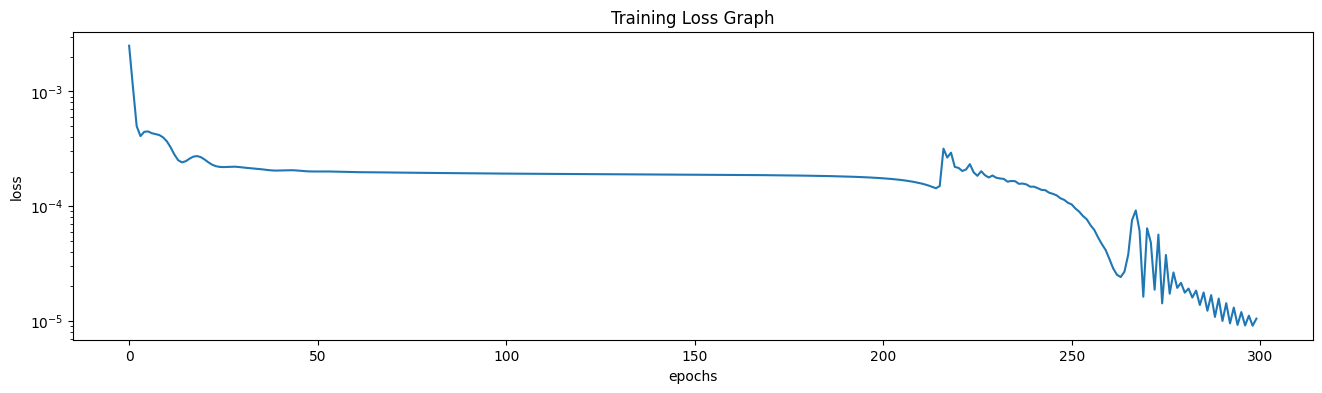

In [5]:
# 데이터 shuffle은 False 설정함
def train(dataset, model, batch_size, n_epochs):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    optimizer = torch.optim.AdamW(model.parameters())# ------------------- Check
#    loss_fn = torch.nn.L1Loss()# ------------------- Check
    loss_fn = torch.nn.MSELoss()# ------------------- Check
    epochs = trange(n_epochs, desc="training")
    best = {"loss": sys.float_info.max}
    loss_history = []
    for e in epochs:
        epoch_loss = 0
        for batch in dataloader:
            optimizer.zero_grad()
            given = batch["given"].to(device)
            guess = model(given).to(device)
            answer = batch["answer"].to(device)
            loss = loss_fn(answer, guess)
            loss.backward()
            epoch_loss += loss.item()
            optimizer.step()
        loss_history.append(epoch_loss)
        epochs.set_postfix_str(f"loss: {epoch_loss:.6f}")
        if epoch_loss < best["loss"]:
            best["state"] = model.state_dict()
            best["loss"] = epoch_loss
            best["epoch"] = e + 1
    return best, loss_history


def train_data():

  # Unique Arbitration_ID 리스트 생성
  dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
  modle_dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/model_data/'
  unique_file_name = f'unique_ids{0}.csv'

  unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})

  # Unique Arbitration_ID 리스트 생성
  # unique_ids = can_normal['Arbitration_ID'].unique()
  skipped = True

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for index,row in unique_ids_pd.iterrows():
    arb_id = row['Arbitration_ID']
    Filenum = f"Nid{arb_id}"

    # if arb_id != '52A':
    #   print(f'arb_id {arb_id} is skipped')
    #   continue

    # if skipped == True:
    #   if arb_id == '251':
    #     skipped = False
    #     print(f'arb_id {arb_id} is skipped')
    #     continue
    #   else:
    #     print(f'arb_id {arb_id} is skipped')
    #     continue

    # 파일명 생성
    normalized_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data'
    file_name = f'pre_train_D_0_ID_{arb_id}.csv'
    file_path = f'{normalized_path}/{file_name}'
    print(file_path)
    can_normal = pd.read_csv(file_path)

    DROP_FIELD = ["Timestamp", "Class0", "Class1"]
    TIMESTAMP_FIELD = "Timestamp"
    ATTACK_FIELD = "Class0"
    VALID_COLUMNS_IN_TRAIN_DATASET = can_normal.columns
    VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD)

    # Data Load & Merge
    TRAIN_DF_RAW = can_normal
    TRAIN_DF = TRAIN_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]

    CAN_DATASET_TRAIN = CANDataset(TRAIN_DF_RAW[TIMESTAMP_FIELD], TRAIN_DF, stride=1)

    MODEL = StackedGRU(n_tags=TRAIN_DF.shape[1])
    MODEL.to(device)

    # Find Best Model
    MODEL.train()
    BEST_MODEL, LOSS_HISTORY = train(CAN_DATASET_TRAIN, MODEL, BATCH_SIZE, EPOCH)
    BEST_MODEL["loss"], BEST_MODEL["epoch"]

    with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + "_" + str(N_HIDDENS) + "_" + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "wb") as f:
        torch.save(
            {
                "state": BEST_MODEL["state"],
                "loss_history": LOSS_HISTORY,
            },
            f,
        )
    print(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + "_" + str(N_HIDDENS) + "_" + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt")
    with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + "_" + str(N_HIDDENS) + "_" + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
        SAVED_MODEL = torch.load(f)

    if device == 'cuda':
      torch.cuda.empty_cache()

    MODEL.load_state_dict(SAVED_MODEL["state"])

    plt.figure(figsize=(16, 4))
    plt.title("Training Loss Graph")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.yscale("log")
    plt.plot(SAVED_MODEL["loss_history"])
    plt.savefig(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_loss.png")
    with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_loss_history.txt", 'w') as f:
        with redirect_stdout(f):
            print(SAVED_MODEL["loss_history"])


    if device == 'cuda':
      torch.cuda.empty_cache()

    # del CAN_DATASET_TRAIN, CAN_DATASET_VALIDATION, CAN_DATASET_TEST

train_data()

In [ ]:
# def inference(dataset, model, batch_size, feature_size):
#     dataloader = DataLoader(dataset, batch_size=batch_size)
#     ts, dist, att = [], [], []

#     dist.append(np.zeros((WINDOW_GIVEN,feature_size)))
#     # dist.append(np.zeros(WINDOW_GIVEN))

#     with torch.no_grad():
#         for batch in dataloader:
#             if len(dist) < 1:
#               dist.append(torch.zeros(batch_size))
#             given = batch["given"].to(device)
#             answer = batch["answer"].to(device)
#             guess = model(given)
#             ts.append(np.array(batch["ts"]))
#             # dist.append(np.mean(torch.abs(answer - guess).cpu().numpy(), axis=1))
#             dist.append(torch.abs(answer - guess).cpu().numpy())
#             try:
#                 att.append(np.array(batch["attack"]))
#             except:
#                 att.append(np.zeros(batch_size))

#     return (
#         np.concatenate(ts),
#         np.concatenate(dist),
#         np.concatenate(att),
#     )


# # Unique Arbitration_ID 리스트 생성
# dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
# modle_dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/model_data/'
# normalized_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data'
# pred2_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/pred2_data'
# pred1_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/pred1_data'

# unique_file_name = f'unique_ids{0}.csv'

# unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
# unique_ids = unique_ids_pd['Arbitration_ID'].to_numpy()

# # Unique Arbitration_ID 리스트 생성
# # unique_ids = can_normal['Arbitration_ID'].unique()

# # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
# for index, row in unique_ids_pd.iterrows():
#   arb_id = row['Arbitration_ID']
#   time_span = row['time_span']

#   if arb_id != '260':
#     print(f'arb_id {arb_id} is skipped')
#     continue

#   print('arb_id = ' + str(arb_id))
#   Filenum = f"Nid{arb_id}"

#   # 파일명 생성
#   file_name = f'pre_train_D_1_ID_{arb_id}.csv'
#   file_path = f'{normalized_path}/{file_name}'
#   print(file_path)
#   can_val = pd.read_csv(file_path)

#   DROP_FIELD = ["Timestamp", "Class0", "Class1"]
#   TIMESTAMP_FIELD = "Timestamp"
#   ATTACK_FIELD = "Class0"
#   VALID_COLUMNS_IN_TRAIN_DATASET = can_val.columns
#   VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD)

#   # Data Load & Merge
#   VALIDATION_DF_RAW = can_val
#   VALIDATION_DF = VALIDATION_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]

#   CAN_DATASET_VALIDATION = CANDataset(VALIDATION_DF_RAW[TIMESTAMP_FIELD], VALIDATION_DF, attacks=VALIDATION_DF_RAW[ATTACK_FIELD])

#   # Model Load
#   with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
#       SAVED_MODEL = torch.load(f, map_location=torch.device(device))

#   MODEL = StackedGRU(n_tags=VALIDATION_DF.shape[1])
#   MODEL.load_state_dict(SAVED_MODEL["state"])

#   MODEL.eval()

# # ts = np.array(VALIDATION_DF_RAW[TIMESTAMP_FIELD],)
# # tag_values = np.array(VALIDATION_DF, dtype=np.float32)

#   # CHECK_TS, CHECK_PRED, CHECK_DIST = predict(VALIDATION_DF, VALIDATION_DF_RAW[TIMESTAMP_FIELD], MODEL, time_span*1.6)
#   CHECK_TS, CHECK_DIST, CHECK_ATT = inference(CAN_DATASET_VALIDATION, MODEL, BATCH_SIZE, VALIDATION_DF.shape[1])

#   ATTACK_LABELS = np.array(VALIDATION_DF_RAW["Class0"])

#   print('Validationdf : ' + str(VALIDATION_DF.shape))
#   print('ATTACK_LABELS: ' + str(ATTACK_LABELS.size))
#   print('CHECK_DIST: ' + str(len(CHECK_DIST)))

#   VALIDATION_DF_RAW["Dist"] = np.mean(np.abs(CHECK_DIST), axis=1)

#   # conf_mat = confusion_matrix(y_true=ATTACK_LABELS, y_pred=CHECK_PRED)
#   # conf_mat

#   # # confusion matrix 시각화
#   # disp = ConfusionMatrixDisplay(conf_mat)
#   # disp.plot()

#   # VALIDATION_DF_RAW["Pred0"] = CHECK_PRED
#   file_path = f'{pred2_path}/{file_name}'
#   VALIDATION_DF_RAW.to_csv(file_path, index=False)

#   dist_df = pd.DataFrame(CHECK_DIST)
#   file_name = f'pre_train_D_0_ID_{arb_id}_dist.csv'
#   file_path = f'{pred1_path}/{file_name}'
#   dist_df.to_csv(file_path, index=False)

### Predict

In [ ]:
def predict(df, timestamps, model, time_span):
    answer_idxs = []
    valid_idxs = []
    pred = []
    dist = []


    with torch.no_grad():
      ts = np.array(timestamps)
      tag_values = np.array(df, dtype=np.float32)
      for i in range(0, len(ts)):
        if(len(valid_idxs) < WINDOW_SIZE-1 ):
          valid_idxs.append(i)
          pred.append(0)
          dist.append(0)
          continue

        if ts[i] - ts[valid_idxs[WINDOW_SIZE-2]] < time_span :
          answer_idxs.append(i)
          pred.append(1) # default attack set
          continue

        else:
          single_record = torch.from_numpy(np.array(df.iloc[valid_idxs], dtype=np.float32))
          given = single_record.unsqueeze(0)

          # print(f'given len is {given.shape}')

          guess = model(given)

          # eval
          # 시간 간격이 붕 떠서 time_span안에 하나도 없으면 다음 레코드를 정상으로 간주
          if len(answer_idxs) == 0:
            # cur_dists = answer.apply(distance_from_point, axis=1, point=guess)
            # cur_dist = LA.norm(torch.from_numpy(df.iloc[i].to_numpy()) - guess, axis=1)
            cur_dist = np.mean(torch.abs(torch.from_numpy(df.iloc[i].to_numpy()) - guess).numpy(), axis=1)
            cur_dist = cur_dist * weight
            # cur_dist = np.mean(torch.abs(torch.from_numpy(df.iloc[i].to_numpy()) - guess).numpy(), axis=1
            if cur_dist < 5:
              dist.append(cur_dist)
              pred.append(0)
              valid_idxs.append(i) # valid index shift right
              valid_idxs.pop(0)
              continue
            else:
              dist.append(0)
              pred.append(1) # default attack set
              continue

          if len(answer_idxs) > 1:
            answerdb = df.iloc[answer_idxs]
            tmpDist = answerdb.apply(dist_norm, axis=1, guess=guess).to_numpy()
            # cur_dist = tmpDist * weight
            # tmpDist = answerdb.apply(dist_norm, axis=1, guess=guess).to_numpy()
            min_idx = np.argmin(tmpDist)
            min_dis = tmpDist[min_idx]
            min_idx = answer_idxs[min_idx]
            dist.extend(tmpDist)
          else:
            # min_dis = LA.norm(torch.from_numpy(df.iloc[answer_idxs[0]].to_numpy()) - guess)
            min_dis = torch.from_numpy(df.iloc[answer_idxs[0]].to_numpy()) - guess
            min_dis = np.mean([m * w for m, w in zip(min_dis, weight)])

            min_idx = answer_idxs[0]
            dist.append(min_dis)

          if min_dis < 3.8:
            pred[min_idx] = 0  # to normal set
            valid_idxs.append(min_idx) # valid index shift right
            valid_idxs.pop(0)

          # answer = torch.from_numpy(np.array(answerdb))
          # answer = torch.from_numpy(np.array(df.iloc[answer_idxs]))
          # min_dis = answerdb['Dist'].iloc[min_idx]


#           min_dis = 10000
#           idx = answer_idxs[0]
#           min_idx = idx
#           for itm in answer:
#             cur_dist = np.mean(torch.abs(itm - guess).numpy(), axis=1)
#             dist.append(cur_dist)
#             if min_dis > cur_dist:
#               min_dis = cur_dist
# #              min_dis = torch.abs(itm - guess).numpy()
#               min_idx = idx
#             idx = idx + 1

          # print(f'answer_idxs[0] is {answer_idxs[0]}')
          # print(f'pred.len is {len(pred)}')
          # print(f'min_idx is {min_idx}')

          answer_idxs = []
          answer_idxs.append(i)
          pred.append(1) # default attack set

      pred[len(pred)-1] = 0
      dist.append(0)
    return (
        ts,
        pred,
        dist
    )

def predict_all():
    answer_idxs = []
    valid_idxs = []
    pred = []
    dist = []

    # Unique Arbitration_ID 리스트 생성
    dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
    modle_dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/model_data/'
    normalized_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data'
    pred0_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/pred0_data'

    unique_file_name = f'unique_ids{0}.csv'

    unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
    unique_ids = unique_ids_pd['Arbitration_ID'].to_numpy()

    # Unique Arbitration_ID 리스트 생성
    # unique_ids = can_normal['Arbitration_ID'].unique()

    # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
    for index, row in unique_ids_pd.iterrows():
      arb_id = row['Arbitration_ID']
      time_span = row['time_span']

      if arb_id != '260':
        print(f'arb_id {arb_id} is skipped')
        continue

      print('arb_id = ' + str(arb_id))
      Filenum = f"Nid{arb_id}"

      # 파일명 생성
      file_name = f'pre_train_D_1_ID_{arb_id}.csv'
      file_path = f'{normalized_path}/{file_name}'
      print(file_path)
      can_val = pd.read_csv(file_path)

      DROP_FIELD = ["Timestamp", "Class0", "Class1"]
      TIMESTAMP_FIELD = "Timestamp"
      ATTACK_FIELD = "Class0"
      VALID_COLUMNS_IN_TRAIN_DATASET = can_val.columns
      VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD)

      # Data Load & Merge
      VALIDATION_DF_RAW = can_val
      VALIDATION_DF = VALIDATION_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]

      CAN_DATASET_VALIDATION = CANDataset(VALIDATION_DF_RAW[TIMESTAMP_FIELD], VALIDATION_DF, attacks=VALIDATION_DF_RAW[ATTACK_FIELD])

      # Model Load
      with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
          SAVED_MODEL = torch.load(f, map_location=torch.device(device))

      MODEL = StackedGRU(n_tags=VALIDATION_DF.shape[1])
      MODEL.load_state_dict(SAVED_MODEL["state"])

      MODEL.eval()

  # ts = np.array(VALIDATION_DF_RAW[TIMESTAMP_FIELD],)
  # tag_values = np.array(VALIDATION_DF, dtype=np.float32)

      CHECK_TS, CHECK_PRED, CHECK_DIST = predict(VALIDATION_DF, VALIDATION_DF_RAW[TIMESTAMP_FIELD], MODEL, time_span*1.6)
      ATTACK_LABELS = np.array(VALIDATION_DF_RAW["Class0"])

      print('Validationdf : ' + str(VALIDATION_DF.shape))
      print('ATTACK_LABELS: ' + str(ATTACK_LABELS.size))
      print('CHECK_PRED: ' + str(len(CHECK_PRED)))
      print('CHECK_DIST: ' + str(len(CHECK_DIST)))
      VALIDATION_DF_RAW["Dist"] = CHECK_DIST

      conf_mat = confusion_matrix(y_true=ATTACK_LABELS, y_pred=CHECK_PRED)
      conf_mat

      # confusion matrix 시각화
      disp = ConfusionMatrixDisplay(conf_mat)
      disp.plot()

      VALIDATION_DF_RAW["Pred0"] = CHECK_PRED
      file_path = f'{pred0_path}/{file_name}'
      VALIDATION_DF_RAW.to_csv(file_path, index=False)


predict_all()

###L1 Value(오차) 추출

Train한 모델에 정상데이터(1번파일)을 입력해서 L1 오차를 계산함 (정상값과 추정값의 차이의 절대값의 평균을 계산)
L1오차가 과도하게 큰 피쳐는 사용하지 않을 계획임(0.02 보다 큰 경우에 해당 피쳐 제거함)

arb_id 260 is skipped
arb_id 329 is skipped
arb_id 38D is skipped
arb_id 420 is skipped
arb_id 421 is skipped
arb_id 153 is skipped
arb_id 220 is skipped
arb_id 340 is skipped
arb_id 389 is skipped
arb_id 47F is skipped
arb_id 130 is skipped
arb_id 140 is skipped
arb_id 251 is skipped
arb_id 2B0 is skipped
arb_id 164 is skipped
arb_id 356 is skipped
arb_id 366 is skipped
arb_id 367 is skipped
arb_id 368 is skipped
arb_id 381 is skipped
arb_id 387 is skipped
arb_id 394 is skipped
arb_id 453 is skipped
arb_id 470 is skipped
arb_id 490 is skipped
arb_id 495 is skipped
arb_id 500 is skipped
arb_id 391 is skipped
arb_id 4F1 is skipped
arb_id 484 is skipped
arb_id 386 is skipped
arb_id 479 is skipped
arb_id 436 is skipped
arb_id 541 is skipped
arb_id 485 is skipped
arb_id 492 is skipped
arb_id 4C9 is skipped
arb_id 48A is skipped
arb_id 58B is skipped
arb_id 48C is skipped
arb_id 544 is skipped
arb_id 553 is skipped
arb_id 50C is skipped
arb_id 52A is skipped
arb_id = 507
drive/MyDrive/Colab

  0%|          | 0/722 [00:00<?, ?it/s]

# of valid windows: 722
Validationdf : (746, 11)
ATTACK_LABELS: 746
CHECK_PRED: 746
CHECK_DIST: 746
arb_id = 5B0
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_0_ID_5B0.csv


  0%|          | 0/51 [00:00<?, ?it/s]

# of valid windows: 51
Validationdf : (75, 1)
ATTACK_LABELS: 75
CHECK_PRED: 75
CHECK_DIST: 75
arb_id = 5CD
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_0_ID_5CD.csv


...

# of valid windows: 50
Validationdf : (74, 8)
ATTACK_LABELS: 74
CHECK_PRED: 74
CHECK_DIST: 74
arb_id = 07F
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_0_ID_07F.csv


  0%|          | 0/50 [00:00<?, ?it/s]

# of valid windows: 50
Validationdf : (74, 25)
ATTACK_LABELS: 74
CHECK_PRED: 74
CHECK_DIST: 74
arb_id = 57F
drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data/pre_train_D_0_ID_57F.csv


  0%|          | 0/13 [00:00<?, ?it/s]

# of valid windows: 13
Validationdf : (37, 1)
ATTACK_LABELS: 37
CHECK_PRED: 37
CHECK_DIST: 37


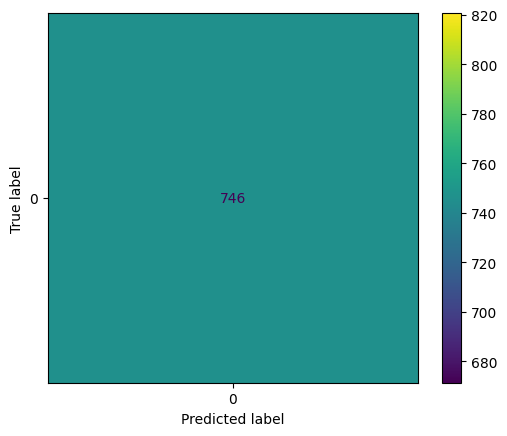

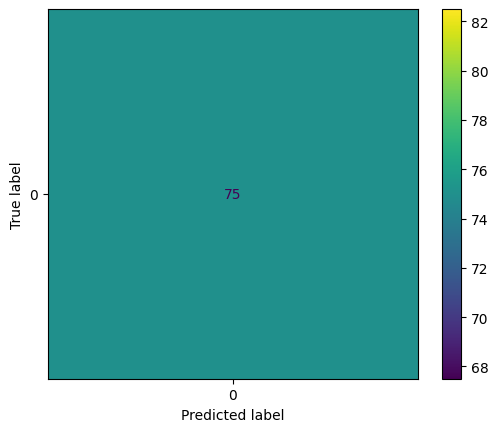

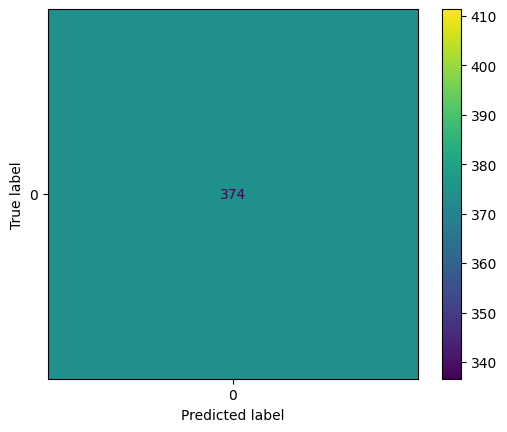

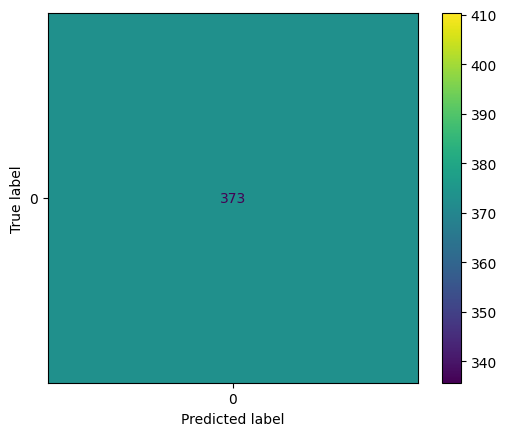

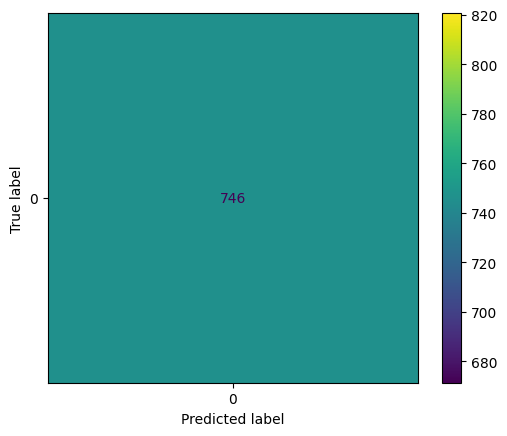

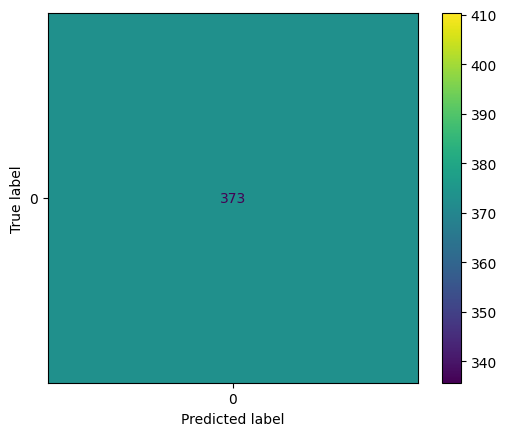

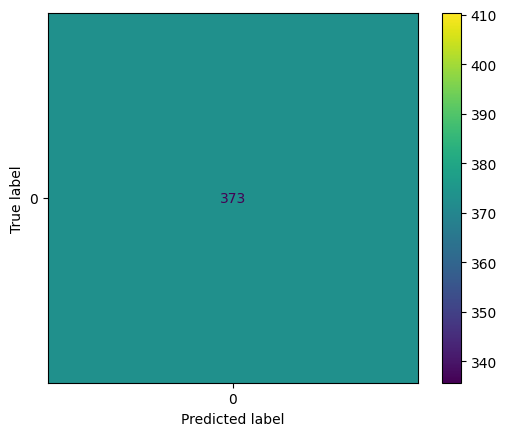

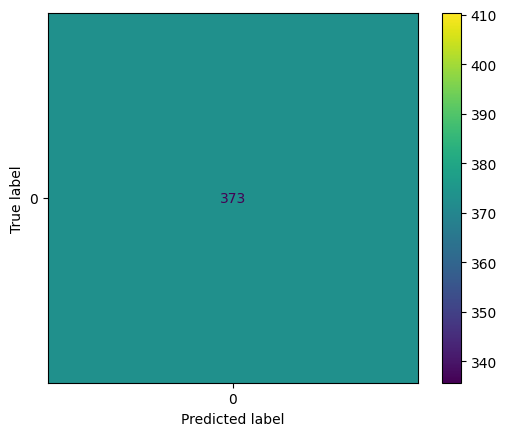

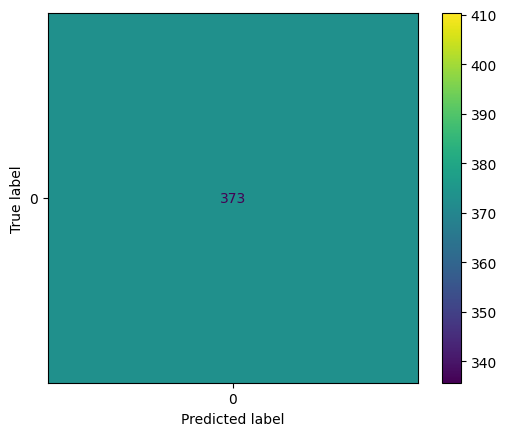

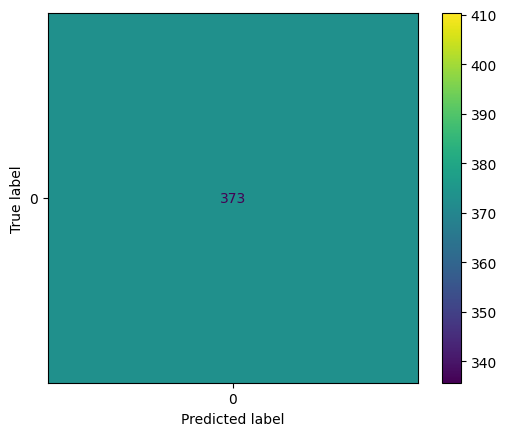

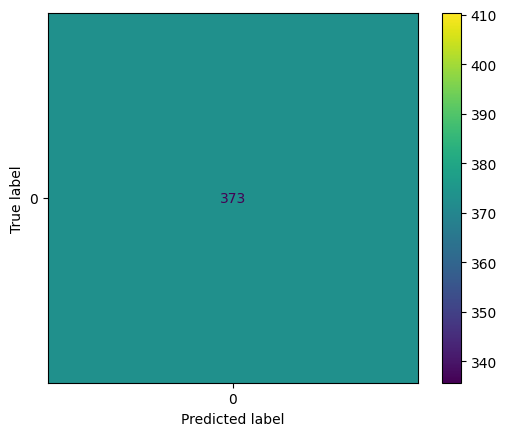

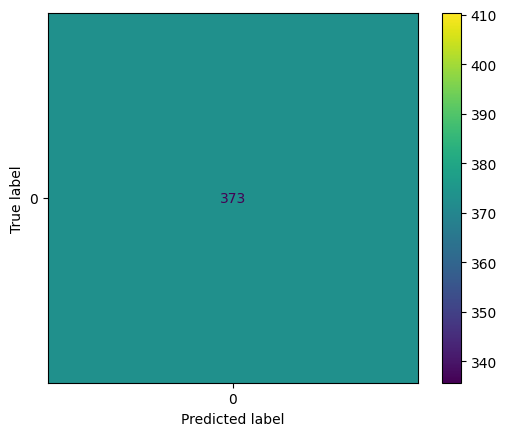

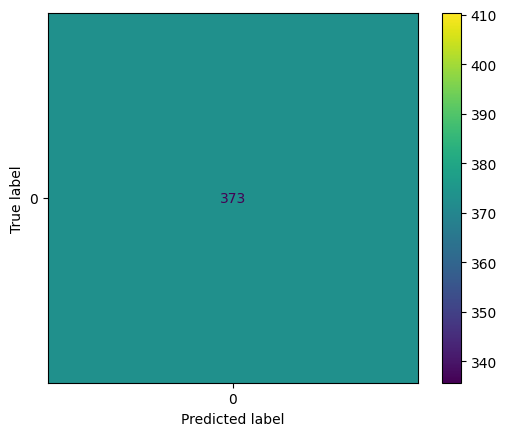

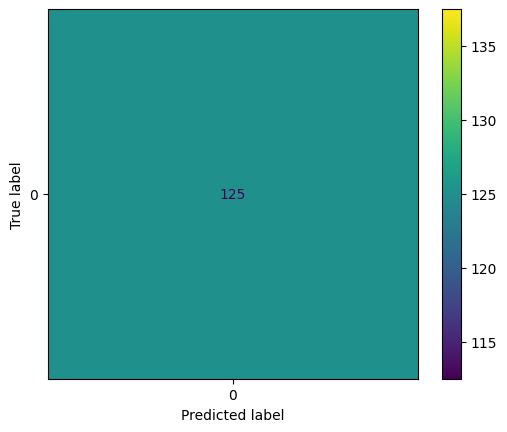

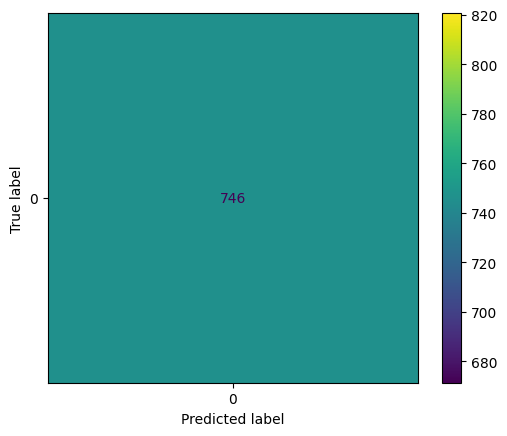

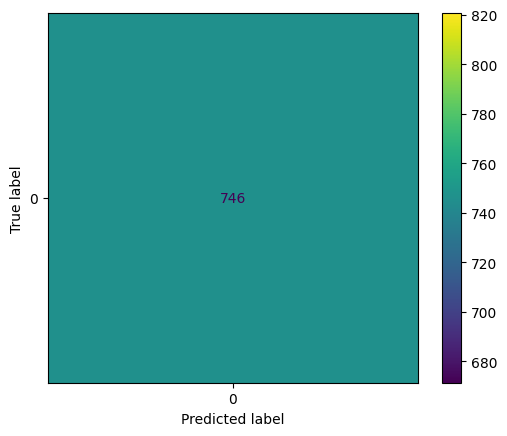

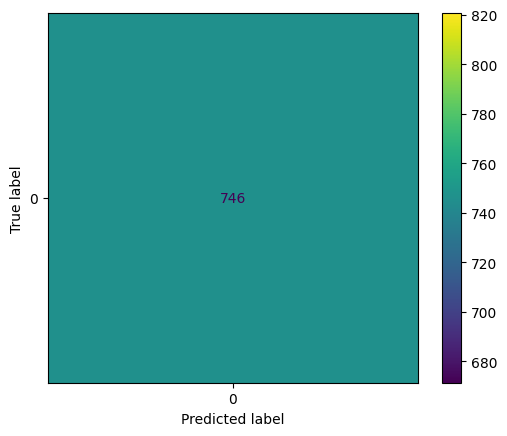

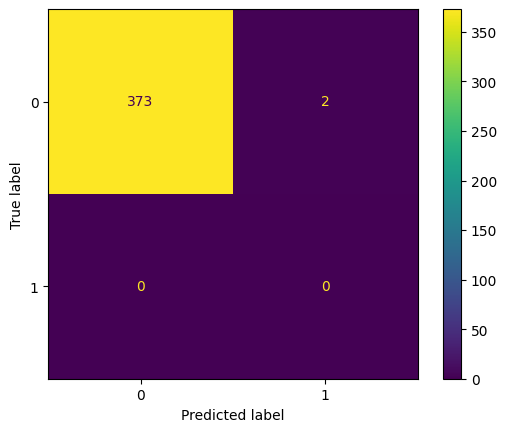

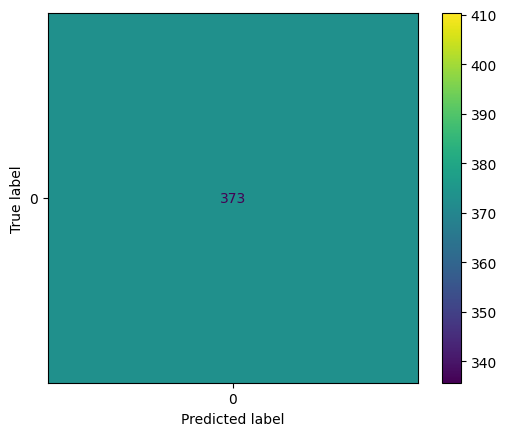

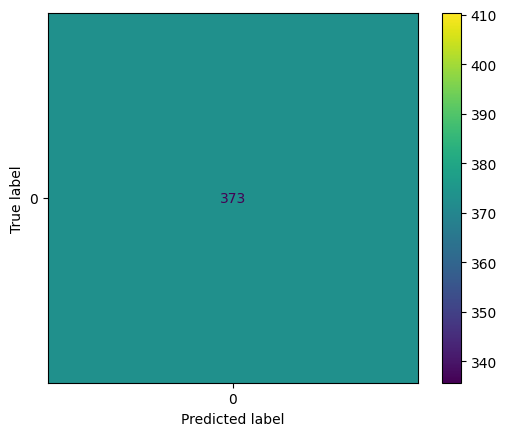

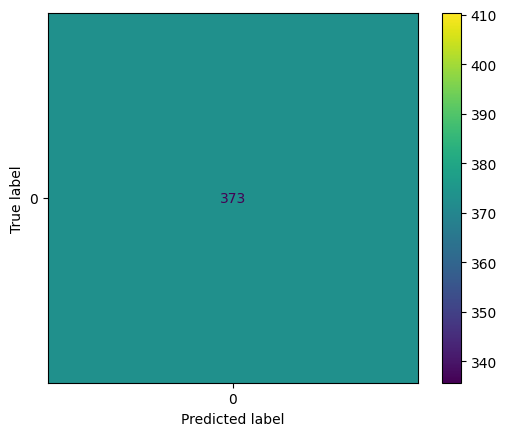

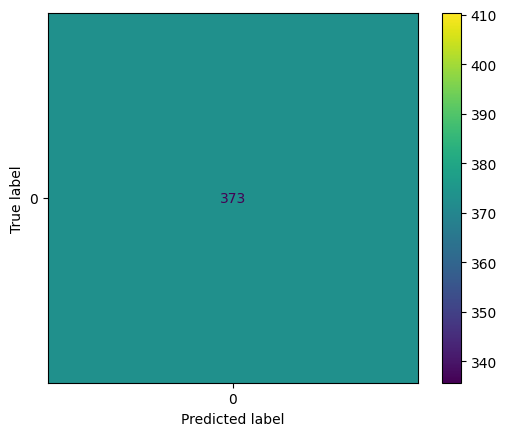

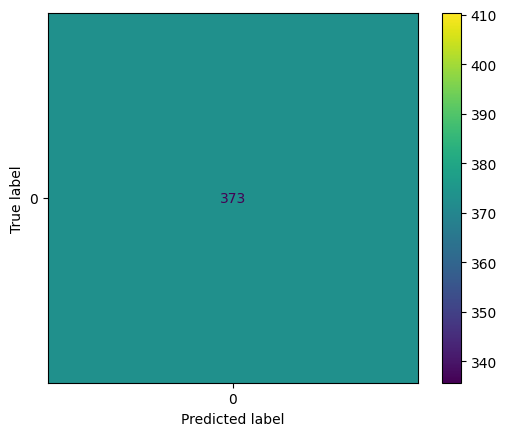

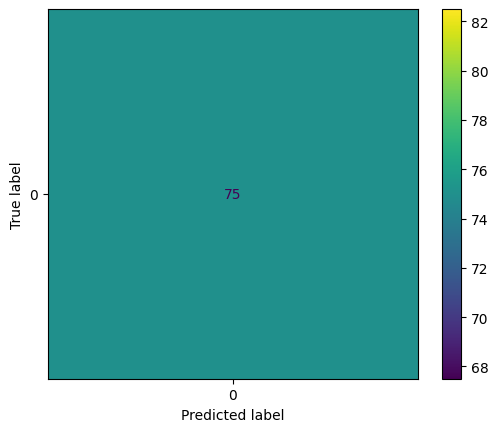

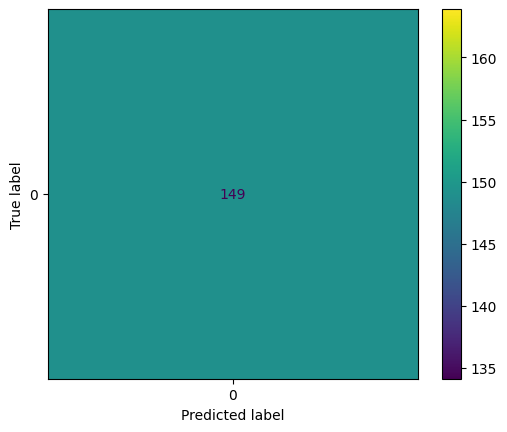

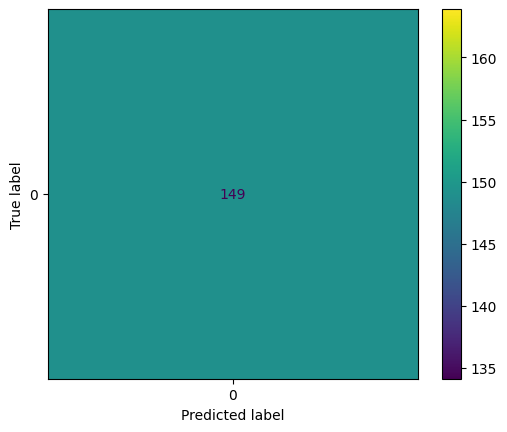

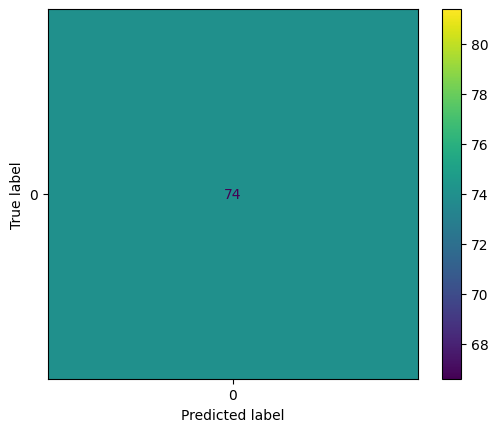

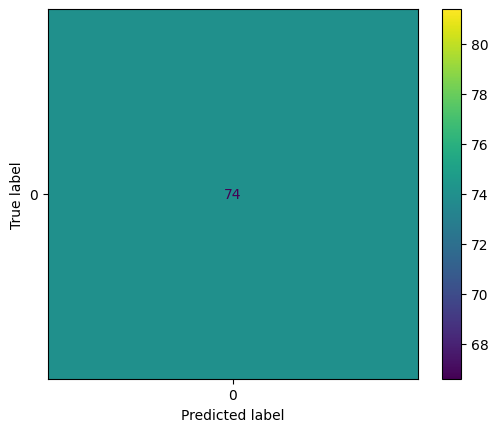

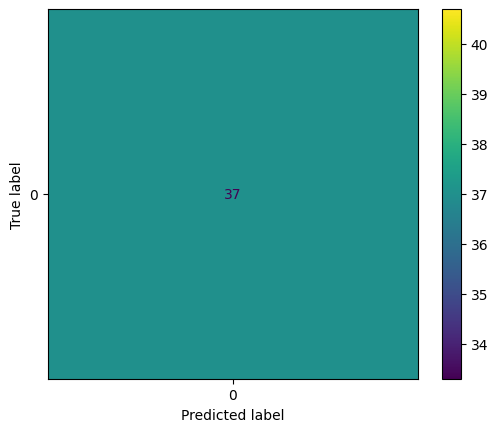

In [43]:
def dist_norm(row, guess):
    return torch.abs(torch.from_numpy(row.to_numpy()) - guess).numpy()

def predict(df, timestamps, model, time_span):
    answer_idxs = []
    valid_idxs = []
    pred = []
    dist = []
    size = len(df.columns)

    with torch.no_grad():
      ts = np.array(timestamps)
      tag_values = np.array(df, dtype=np.float32)
      for i in range(0, len(ts)):
        if(len(valid_idxs) < WINDOW_SIZE-1 ):
          valid_idxs.append(i)
          pred.append(0)
          dist.append(np.zeros(size))
          continue

        if ts[i] - ts[valid_idxs[WINDOW_SIZE-2]] < time_span :
          answer_idxs.append(i)
          pred.append(1) # default attack set
          continue

        else:
          single_record = torch.from_numpy(np.array(df.iloc[valid_idxs], dtype=np.float32))
          given = single_record.unsqueeze(0)

          # print(f'given len is {given.shape}')

          guess = model(given)

          # eval
          # 시간 간격이 붕 떠서 time_span안에 하나도 없으면 다음 레코드를 정상으로 간주
          if len(answer_idxs) == 0:
            cur_dist = torch.abs(torch.from_numpy(df.iloc[i].to_numpy()) - guess).numpy()
            if cur_dist < 5:
              dist.extend(np.array(cur_dist))
              pred.append(0)
              valid_idxs.append(i) # valid index shift right
              valid_idxs.pop(0)
              continue
            else:
              dist.append(np.zeros(size))
              pred.append(1) # default attack set
              continue

          if len(answer_idxs) > 1:
            answerdb = df.iloc[answer_idxs]
            tmpDist = answerdb.apply(dist_norm, axis=1, guess=guess).to_numpy()
            print(tmpDist[0].shape)
            # means= tmpDist.mean(axis=1)
            means = [np.mean(arr) for arr in tmpDist]
            answer_idxs = np.array(answer_idxs)

            # tmpDist = answerdb.apply(dist_norm, axis=1, guess=guess).to_numpy()
            min_idx = np.argmin(means)
            min_dis = tmpDist[min_idx]
            min_idx = answer_idxs[min_idx]
            dist.extend(np.concatenate(tmpDist))
          else:
            min_dis = torch.abs(torch.from_numpy(df.iloc[answer_idxs[0]].to_numpy()) - guess).numpy()
            min_idx = answer_idxs[0]
            dist.extend(np.array(min_dis))

          pred[min_idx] = 0  # to normal set
          valid_idxs.append(min_idx) # valid index shift right
          valid_idxs.pop(0)

          answer_idxs = []
          answer_idxs.append(i)
          pred.append(1) # default attack set

      pred[len(pred)-1] = 0
      dist.append(np.zeros(size))
    return (
        ts,
        pred,
        dist
    )

def predict_all():
    answer_idxs = []
    valid_idxs = []
    pred = []
    dist = []

    # Unique Arbitration_ID 리스트 생성
    dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
    modle_dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/model_data/'
    normalized_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/normalized_data'
    pred1_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/pred1_data'

    unique_file_name = f'unique_ids{0}.csv'

    unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
    unique_ids = unique_ids_pd['Arbitration_ID'].to_numpy()

    # Unique Arbitration_ID 리스트 생성
    # unique_ids = can_normal['Arbitration_ID'].unique()
    skipped = True
    # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
    for index, row in unique_ids_pd.iterrows():
      arb_id = row['Arbitration_ID']
      time_span = row['time_span']

      if skipped == True:
        if arb_id == '52A':
          skipped = False
          print(f'arb_id {arb_id} is skipped')
          continue
        else:
          print(f'arb_id {arb_id} is skipped')
          continue

      print('arb_id = ' + str(arb_id))
      Filenum = f"Nid{arb_id}"

      # 파일명 생성
      file_name = f'pre_train_D_0_ID_{arb_id}.csv'
      file_path = f'{normalized_path}/{file_name}'
      print(file_path)
      can_val = pd.read_csv(file_path)

      DROP_FIELD = ["Timestamp", "Class0", "Class1"]
      TIMESTAMP_FIELD = "Timestamp"
      ATTACK_FIELD = "Class0"
      VALID_COLUMNS_IN_TRAIN_DATASET = can_val.columns
      VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD)

      # Data Load & Merge
      VALIDATION_DF_RAW = can_val
      VALIDATION_DF = VALIDATION_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]

      CAN_DATASET_VALIDATION = CANDataset(VALIDATION_DF_RAW[TIMESTAMP_FIELD], VALIDATION_DF, attacks=VALIDATION_DF_RAW[ATTACK_FIELD])

      # Model Load
      with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
          SAVED_MODEL = torch.load(f, map_location=torch.device(device))

      MODEL = StackedGRU(n_tags=VALIDATION_DF.shape[1])
      MODEL.load_state_dict(SAVED_MODEL["state"])

      MODEL.eval()

  # ts = np.array(VALIDATION_DF_RAW[TIMESTAMP_FIELD],)
  # tag_values = np.array(VALIDATION_DF, dtype=np.float32)

      CHECK_TS, CHECK_PRED, CHECK_DIST = predict(VALIDATION_DF, VALIDATION_DF_RAW[TIMESTAMP_FIELD], MODEL, time_span*1.6)
      ATTACK_LABELS = np.array(VALIDATION_DF_RAW["Class0"])

      print('Validationdf : ' + str(VALIDATION_DF.shape))
      print('ATTACK_LABELS: ' + str(ATTACK_LABELS.size))
      print('CHECK_PRED: ' + str(len(CHECK_PRED)))
      print('CHECK_DIST: ' + str(len(CHECK_DIST)))
      VALIDATION_DF_RAW["Dist"] = CHECK_DIST

      # conf_mat = confusion_matrix(y_true=ATTACK_LABELS, y_pred=CHECK_PRED)
      # conf_mat

      # # confusion matrix 시각화
      # disp = ConfusionMatrixDisplay(conf_mat)
      # disp.plot()

      VALIDATION_DF_RAW["Pred0"] = CHECK_PRED
      file_path = f'{pred1_path}/{file_name}'
      VALIDATION_DF_RAW.to_csv(file_path, index=False)
      column_sums = np.array(CHECK_DIST).mean(axis=0).T
      dist_df = pd.DataFrame(column_sums)
      #dist_df = pd.DataFrame(CHECK_DIST)
      file_name = f'pre_train_D_0_ID_{arb_id}_dist.csv'
      file_path = f'{pred1_path}/{file_name}'
      dist_df.to_csv(file_path, index=False)


predict_all()

### New Normalized

L1 오차값이 0.02보다 큰 경우는 해당 피쳐를 제거하고 정규화를 다시 수행함.

In [44]:
from pprint import pprint
import json
from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#print(scaler.fit(data))
#print(scaler.transform(data))

def is_dict_string(s):
    try:
        # 문자열을 파싱 시도
        parsed = json.loads(s)
        # 파싱한 결과가 dict인지 확인
        if isinstance(parsed, dict):
            return True
        else:
            return False
    except (ValueError, TypeError):
        # 파싱 오류가 발생하면 dict가 아님
        return False

# 각 weight의 제곱을 구한 후, 1.0 / (w * 200) 과 1.0 중 작은 값을 선택
# weight = [np.min([1.0 / (w**2 * 200), 1.0]) for w in weight]
# weight = np.minimum(1.0 / (weight**2 * 200), 1.0)
# weight = [np.where(w > 0.1, 0, w) for w in weight]
# weight = [np.min([1.0 / (w**2 * 200), 1.0]) for w in weight]

def weight_norm(row, weight):
    return [m * w for m, w in zip(row, weight)]

def normaliz_data():
  # Unique Arbitration_ID 리스트 생성
  dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
  unique_file_name = f'unique_ids{0}.csv'

  unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})

  # Unique Arbitration_ID 리스트 생성
  # unique_ids = can_normal['Arbitration_ID'].unique()
  skipped = True
  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for index, row in unique_ids_pd.iterrows():
    arb_id = row['Arbitration_ID']


    # if skipped == True:
    #   if arb_id == '52A':
    #     skipped = False
    #     print(f'arb_id {arb_id} is skipped')
    #     continue
    #   else:
    #     print(f'arb_id {arb_id} is skipped')
    #     continue

    # if(arb_id != '52A'):
    #   continue


    #
    # 파일명 생성
    decoded_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data'
    pred1_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/pred1_data'
    file_name = f'pre_train_D_0_ID_{arb_id}_dist.csv'
    file_path = f'{pred1_path}/{file_name}'
    weight_df = pd.read_csv(file_path)
    weight = weight_df.to_numpy().T[0]

    weight = [np.where(w > 0.02, 0, 1) for w in weight]

    i = 0
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{decoded_path}/{file_name}'
    print(file_path)
    can_normal = pd.read_csv(file_path)

    i = 1
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{decoded_path}/{file_name}'
    can_val = pd.read_csv(file_path)

    i = 2
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{decoded_path}/{file_name}'
    can_test = pd.read_csv(file_path)
    decodedstring = can_normal['Decoded'].values[0]
    if can_normal.columns.size > 19:
      DROP_FIELD = ["Timestamp", "DLC", "D0","D1", "D2", "D3", "D4", "D5", "D6", "D7",
                    "Arbitration_ID", "Class", "SubClass", "Class0", "Class1", "Data", "Hex_ID", "Hex_Data", "Decoded"]
    else:
      DROP_FIELD = ["Timestamp","DLC",
                    "Arbitration_ID", "Class", "SubClass", "Class0", "Class1", "Data", "Hex_ID", "Hex_Data", "Decoded"]

    # Data Load & Merge
    TRAIN_DF_RAW = can_normal
    VALIDATION_DF_RAW = can_val
    TEST_DF_RAW = can_test


    TIMESTAMP_FIELD = "Timestamp"
    ATTACK_FIELD = "Class0"
    VALID_COLUMNS_IN_TRAIN_DATASET = TRAIN_DF_RAW.columns
    VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD) # DROP_FIELD를 통해 normalization에 사용하지 않을 변수를 제거함.

    TRAIN_DF = TRAIN_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
    # 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
    TRAIN_DF = TRAIN_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)

    VALIDATION_DF_RAW1 = VALIDATION_DF_RAW[VALIDATION_DF_RAW['Class0']==0]

    VALIDATION_DF1 = VALIDATION_DF_RAW1[VALID_COLUMNS_IN_TRAIN_DATASET]
    VALIDATION_DF1 = VALIDATION_DF1.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)
    VALIDATION_DF = VALIDATION_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
    # 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
    VALIDATION_DF = VALIDATION_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)

    TEST_DF = TEST_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]
    # 모든 값을 float으로 변환하고, 변환이 불가능한 값은 0.0으로 대체
    TEST_DF = TEST_DF.applymap(lambda x: pd.to_numeric(x, errors='coerce')).fillna(0.0)

    TAG_MIN = np.min([TRAIN_DF.min(), VALIDATION_DF1.min()], axis=0)
    TAG_MAX = np.max([TRAIN_DF.max(), VALIDATION_DF1.max()], axis=0)

    scaler = MinMaxScaler()
    # print(scaler.fit(data))
    # print(scaler.transform(data))

    # # Min-Max Normalize
    scaler.fit(np.array([TAG_MIN,TAG_MAX]).reshape(2,-1))
#  scaler.fit(TRAIN_DF)

    # TRAIN_DF = pd.DataFrame(scaler.transform(TRAIN_DF), columns = TRAIN_DF.columns)
    # TRAIN_DF = TRAIN_DF.apply(lambda row: weight_norm(row, weight), axis=1, result_type='expand')
    # TRAIN_DF = pd.DataFrame(TRAIN_DF, columns = TRAIN_DF.columns)

    # TRAIN_DF를 스케일링 후 데이터프레임으로 변환
    TRAIN_DF = pd.DataFrame(scaler.transform(TRAIN_DF), columns=TRAIN_DF.columns)
    TRAIN_DF = TRAIN_DF.mul(weight, axis=1)

    VALIDATION_DF = pd.DataFrame(scaler.transform(VALIDATION_DF), columns=VALIDATION_DF.columns)
    VALIDATION_DF = VALIDATION_DF.mul(weight, axis=1)

    TEST_DF = pd.DataFrame(scaler.transform(TEST_DF), columns=TEST_DF.columns)
    TEST_DF = TEST_DF.mul(weight, axis=1)

    TRAIN_DF["Timestamp"] = TRAIN_DF_RAW["Timestamp"]
    TRAIN_DF["Class0"] = TRAIN_DF_RAW["Class0"]
    TRAIN_DF["Class1"] = TRAIN_DF_RAW["Class1"]

    VALIDATION_DF["Timestamp"] = VALIDATION_DF_RAW["Timestamp"]
    VALIDATION_DF["Class0"] = VALIDATION_DF_RAW["Class0"]
    VALIDATION_DF["Class1"] = VALIDATION_DF_RAW["Class1"]

    TEST_DF["Timestamp"] = TEST_DF_RAW["Timestamp"]
    TEST_DF["Class0"] = TEST_DF_RAW["Class0"]
    TEST_DF["Class1"] = TEST_DF_RAW["Class1"]

    normalized_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/NewNormalized_data'

    i = 0
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{normalized_path}/{file_name}'
    TRAIN_DF.to_csv(file_path, index=False)
    i = 1
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{normalized_path}/{file_name}'
    VALIDATION_DF.to_csv(file_path, index=False)
    i = 2
    file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
    file_path = f'{normalized_path}/{file_name}'
    TEST_DF.to_csv(file_path, index=False)
    print(file_path)


normaliz_data()

# WINDOW_GIVEN_LIST = [49]
# # Model Config
# Filenum = "E(50)_"
# N_HIDDENS = 100 #
# N_LAYERS = 2 #
# EPOCH = 150 #
# #EPOCH = 1 #
# WINDOW_GIVEN = WINDOW_GIVEN_LIST[0]
# BATCH_SIZE = 1024
# WINDOW_SIZE = WINDOW_GIVEN + 1
# THRESHOLD = 0.2

arb_id 260 is skipped
arb_id 329 is skipped
arb_id 38D is skipped
arb_id 420 is skipped
arb_id 421 is skipped
arb_id 153 is skipped
arb_id 220 is skipped
arb_id 340 is skipped
arb_id 389 is skipped
arb_id 47F is skipped
arb_id 130 is skipped
arb_id 140 is skipped
arb_id 251 is skipped
arb_id 2B0 is skipped
arb_id 164 is skipped
arb_id 356 is skipped
arb_id 366 is skipped
arb_id 367 is skipped
arb_id 368 is skipped
arb_id 381 is skipped
arb_id 387 is skipped
arb_id 394 is skipped
arb_id 453 is skipped
arb_id 470 is skipped
arb_id 490 is skipped
arb_id 495 is skipped
arb_id 500 is skipped
arb_id 391 is skipped
arb_id 4F1 is skipped
arb_id 484 is skipped
arb_id 386 is skipped
arb_id 479 is skipped
arb_id 436 is skipped
arb_id 541 is skipped
arb_id 485 is skipped
arb_id 492 is skipped
arb_id 4C9 is skipped
arb_id 48A is skipped
arb_id 58B is skipped
arb_id 48C is skipped
arb_id 544 is skipped
arb_id 553 is skipped
arb_id 50C is skipped
arb_id 52A is skipped
drive/MyDrive/Colab Notebooks/CA

###New Train

arb_id 260 is skipped
arb_id 329 is skipped
arb_id 38D is skipped
arb_id 420 is skipped
arb_id 421 is skipped
arb_id 153 is skipped
arb_id 220 is skipped
arb_id 340 is skipped
arb_id 389 is skipped
arb_id 47F is skipped
arb_id 130 is skipped
arb_id 140 is skipped
arb_id 251 is skipped
arb_id 2B0 is skipped
arb_id 164 is skipped
arb_id 356 is skipped
arb_id 366 is skipped
arb_id 367 is skipped
arb_id 368 is skipped
arb_id 381 is skipped
arb_id 387 is skipped
arb_id 394 is skipped
arb_id 453 is skipped
arb_id 470 is skipped
arb_id 490 is skipped
arb_id 495 is skipped
arb_id 500 is skipped
arb_id 391 is skipped
arb_id 4F1 is skipped
arb_id 484 is skipped
arb_id 386 is skipped
arb_id 479 is skipped
arb_id 436 is skipped
arb_id 541 is skipped
arb_id 485 is skipped
arb_id 492 is skipped
arb_id 4C9 is skipped
arb_id 48A is skipped
arb_id 58B is skipped
arb_id 48C is skipped
arb_id 544 is skipped
arb_id 553 is skipped
arb_id 50C is skipped
arb_id 52A is skipped
drive/MyDrive/Colab Notebooks/CA

  0%|          | 0/722 [00:00<?, ?it/s]

# of valid windows: 722


training:   0%|          | 0/300 [00:00<?, ?it/s]

drive/MyDrive/Colab Notebooks/CAN_IDS/NewNormalized_data/pre_train_D_0_ID_5B0.csv


...

training:   0%|          | 0/300 [00:00<?, ?it/s]

drive/MyDrive/Colab Notebooks/CAN_IDS/NewNormalized_data/pre_train_D_0_ID_57F.csv


  0%|          | 0/13 [00:00<?, ?it/s]

# of valid windows: 13


training:   0%|          | 0/300 [00:00<?, ?it/s]

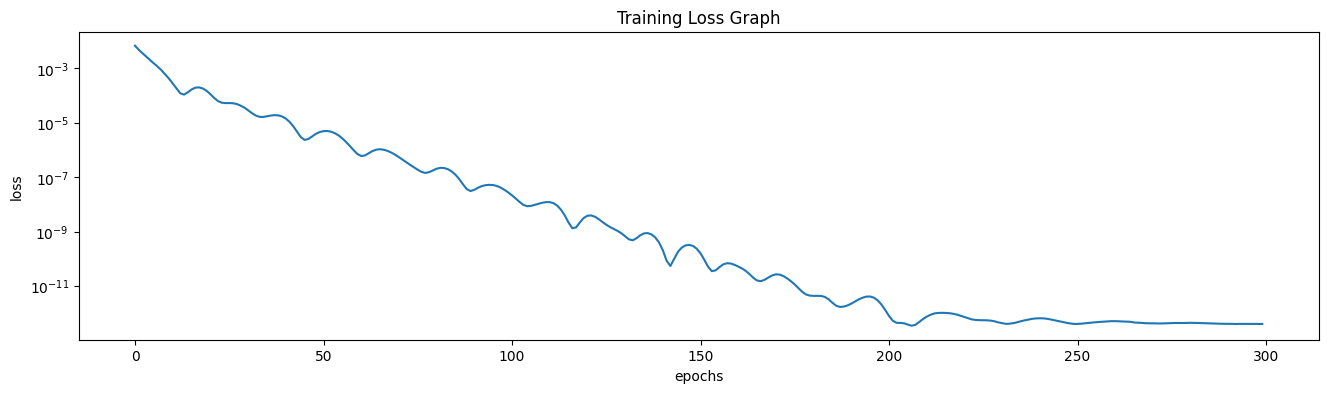

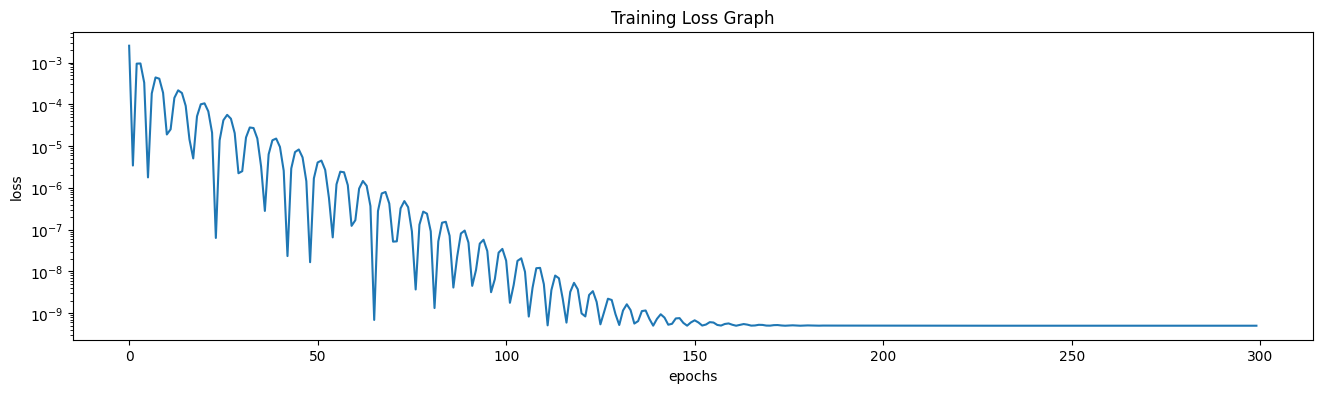

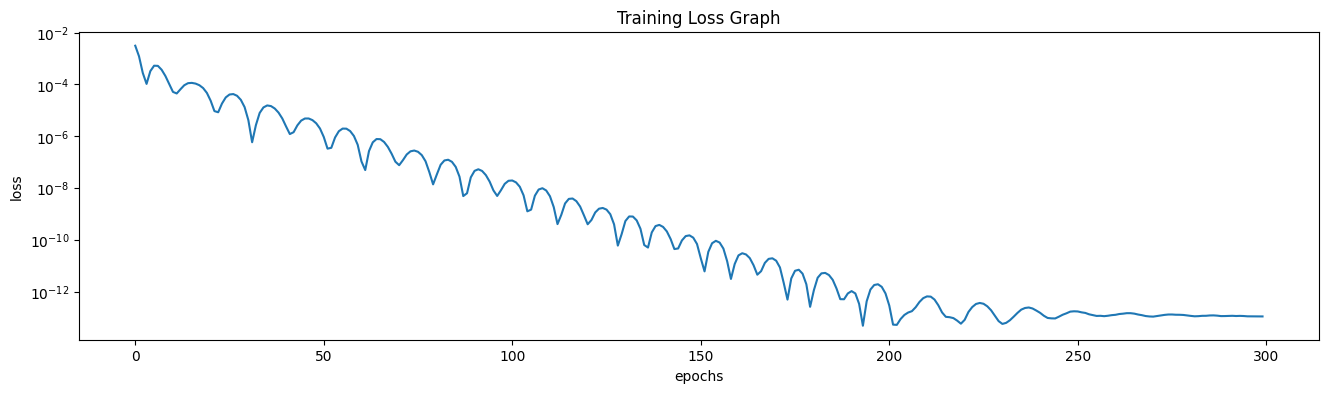

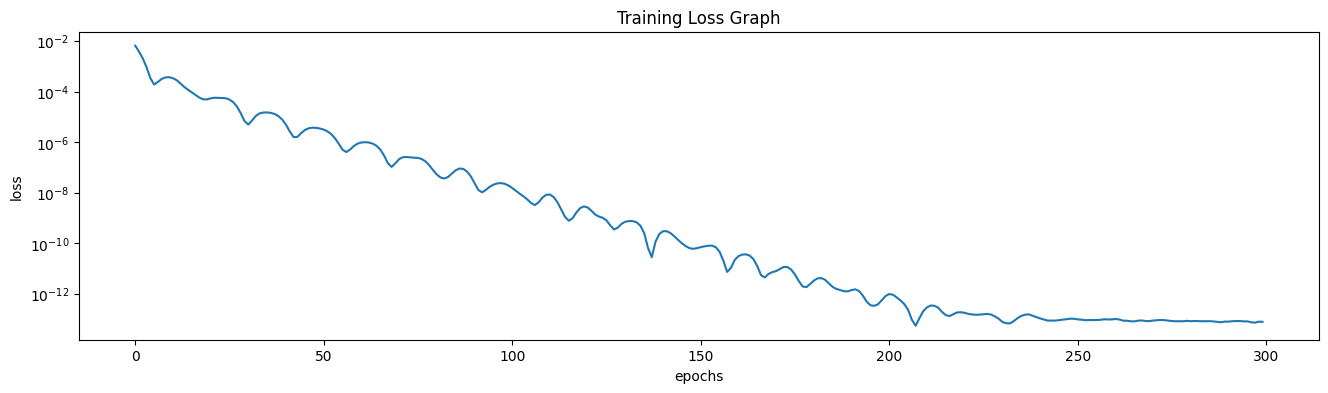

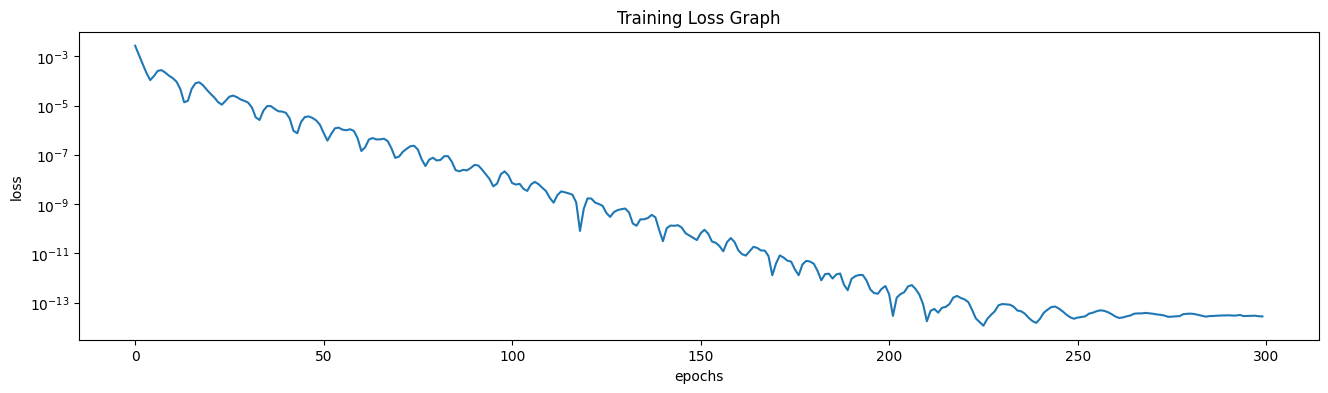

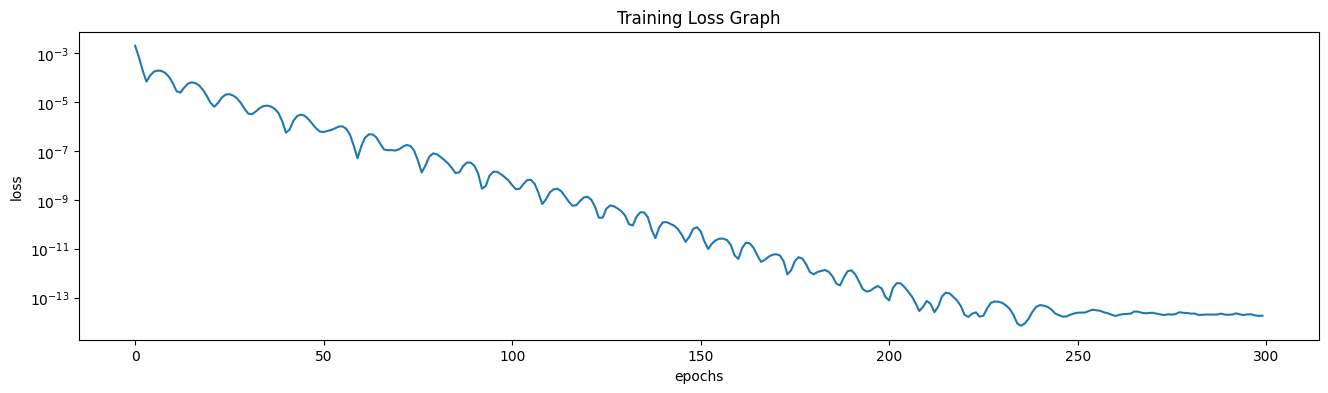

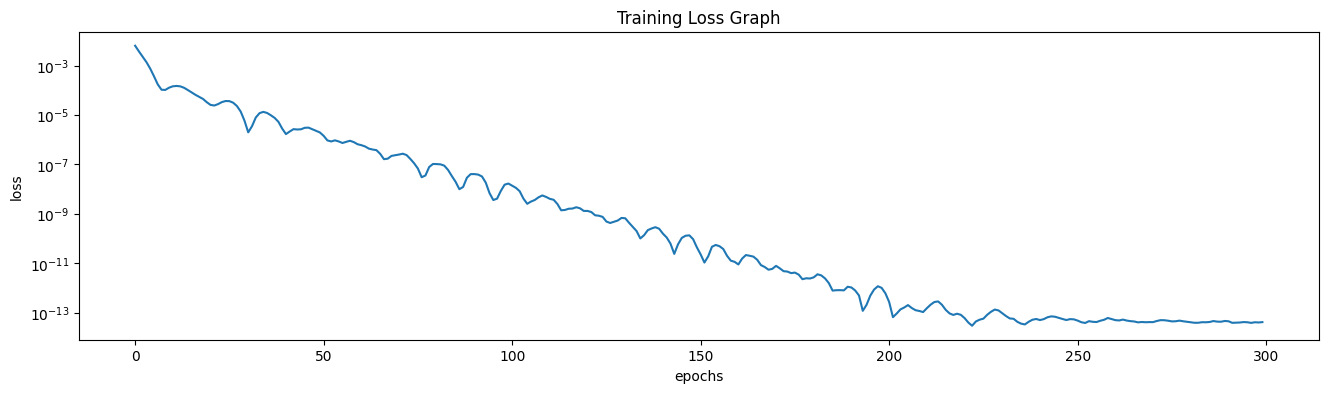

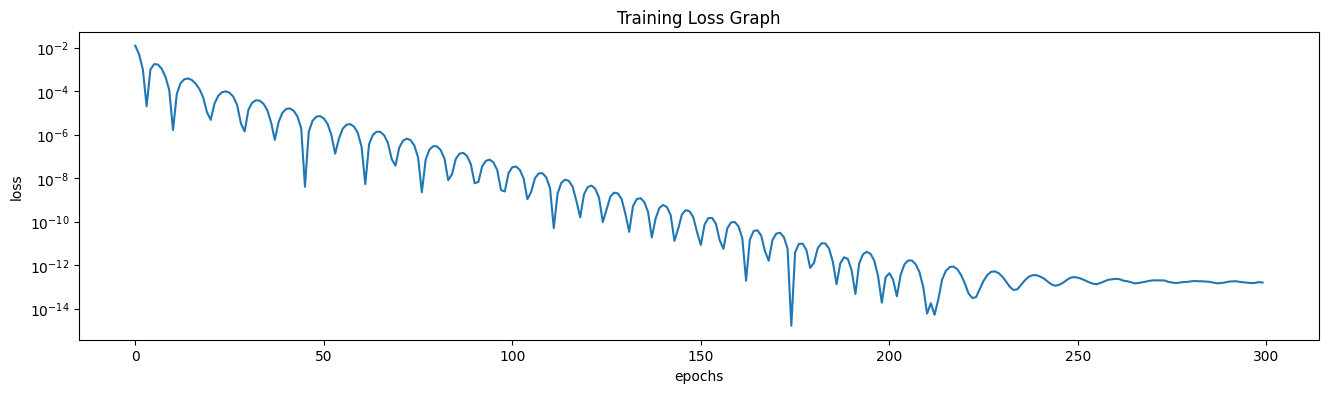

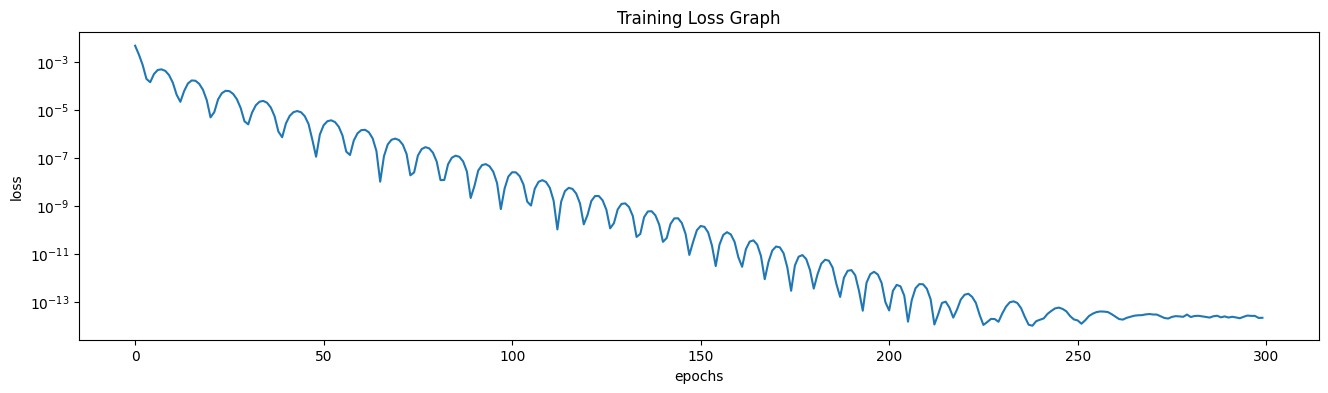

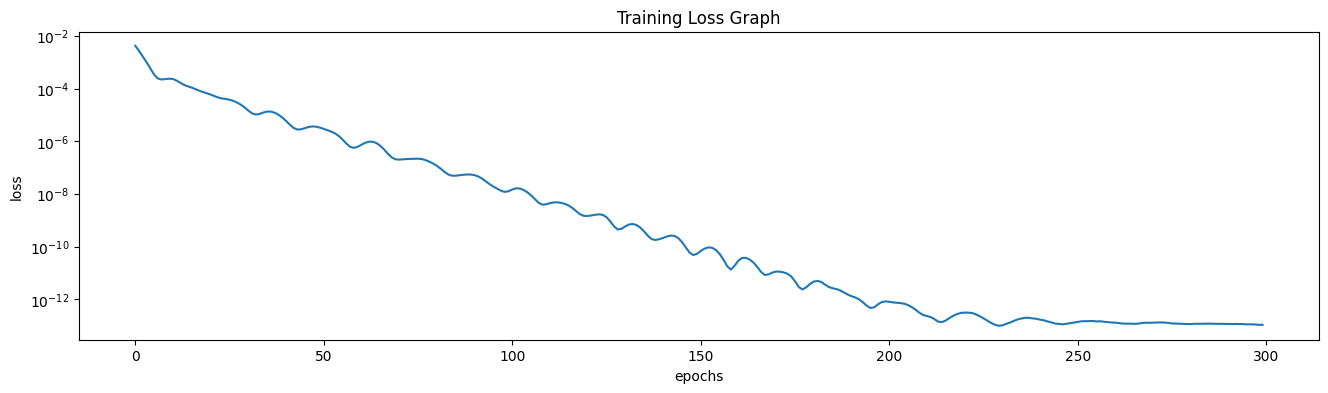

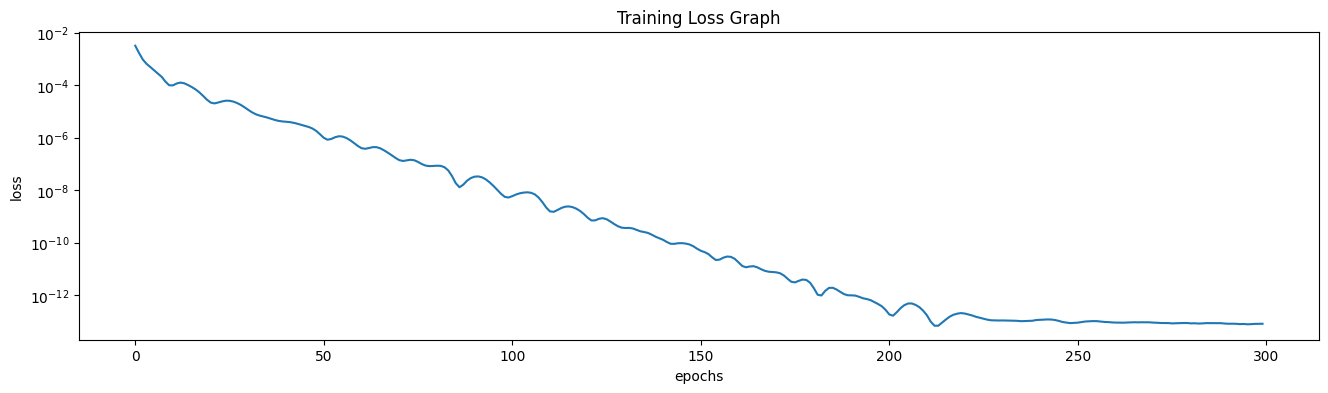

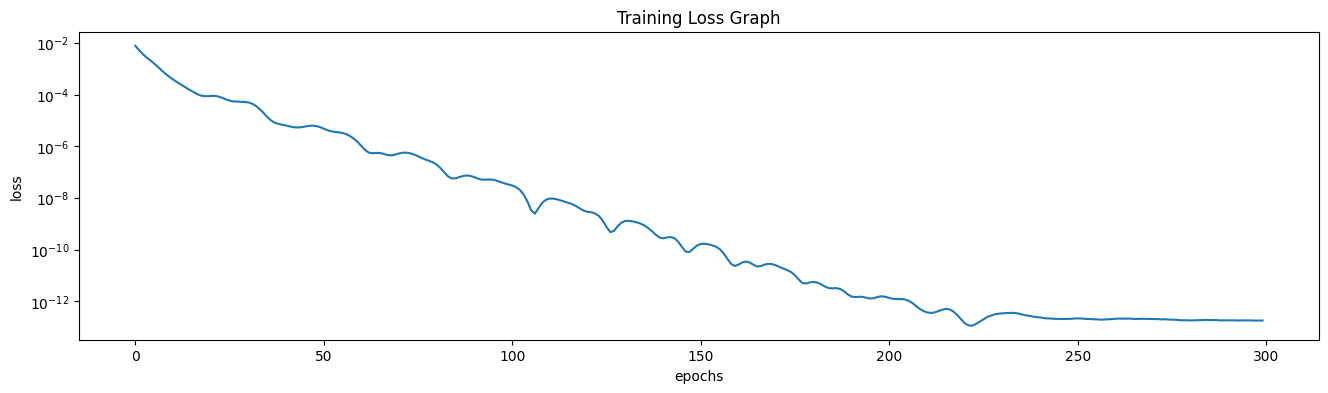

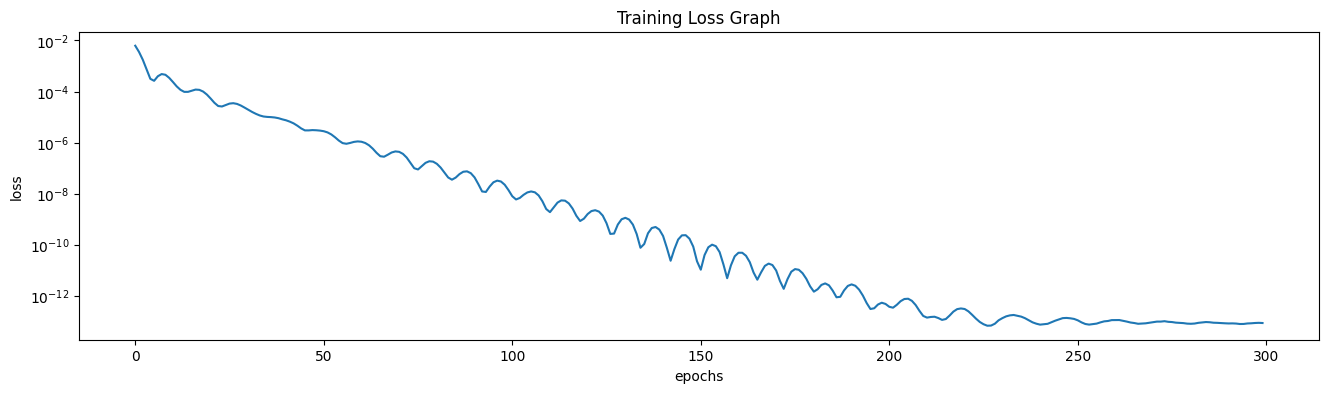

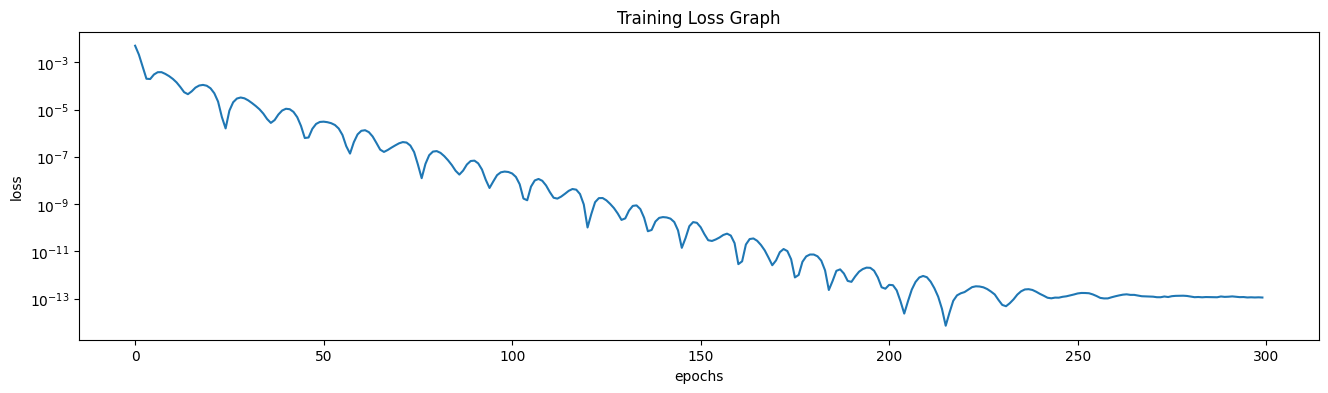

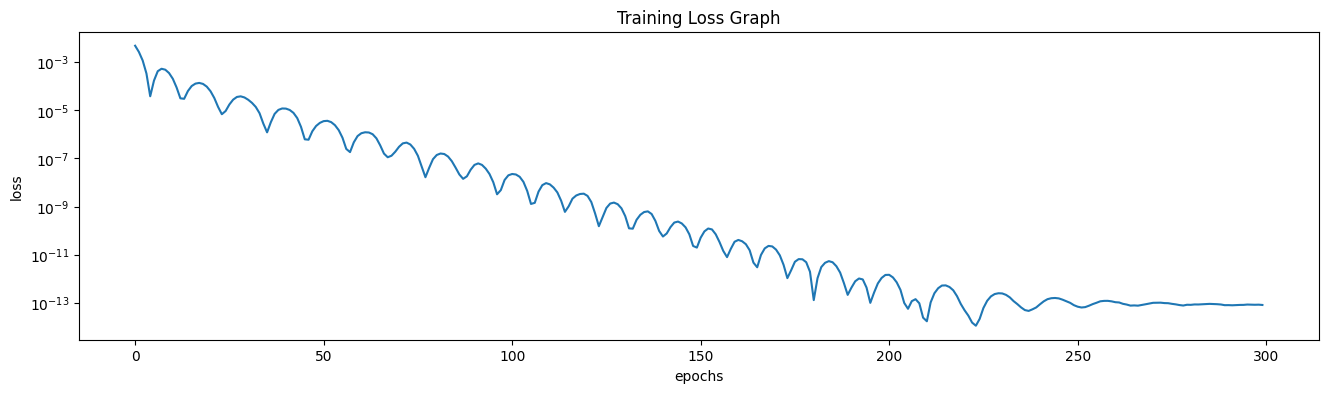

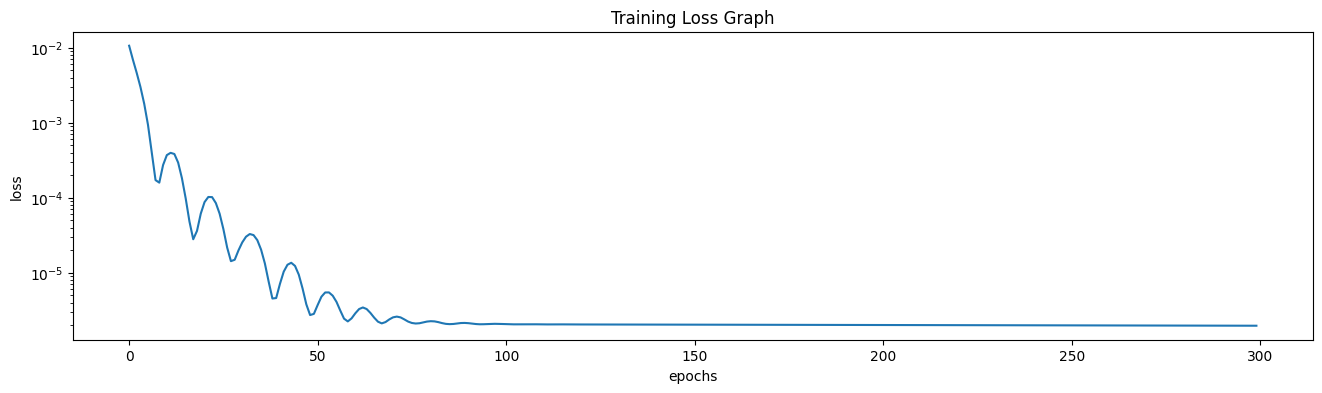

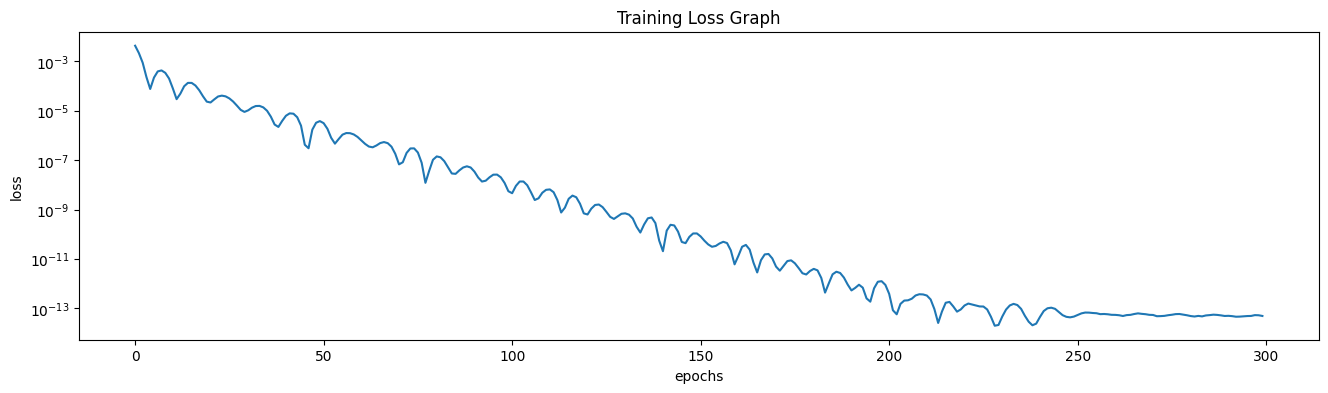

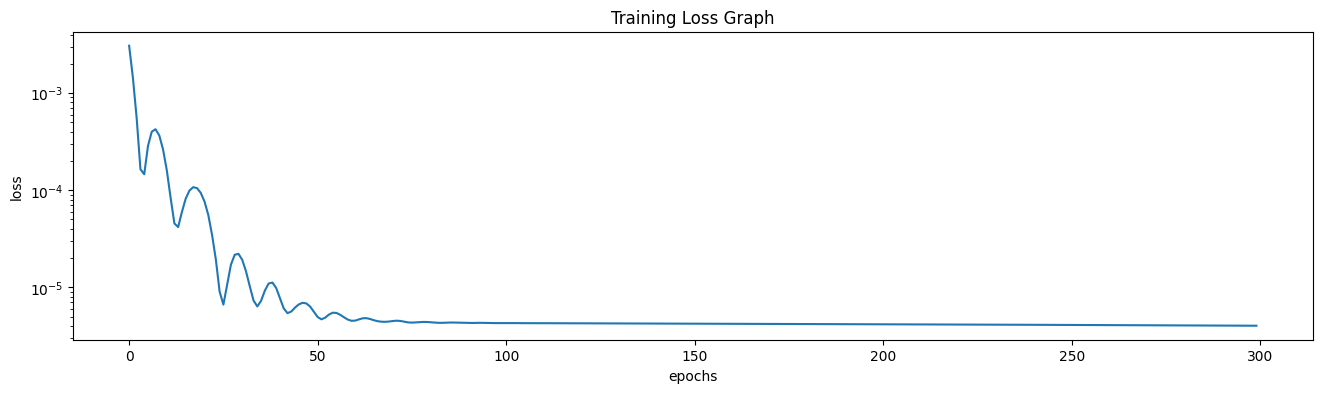

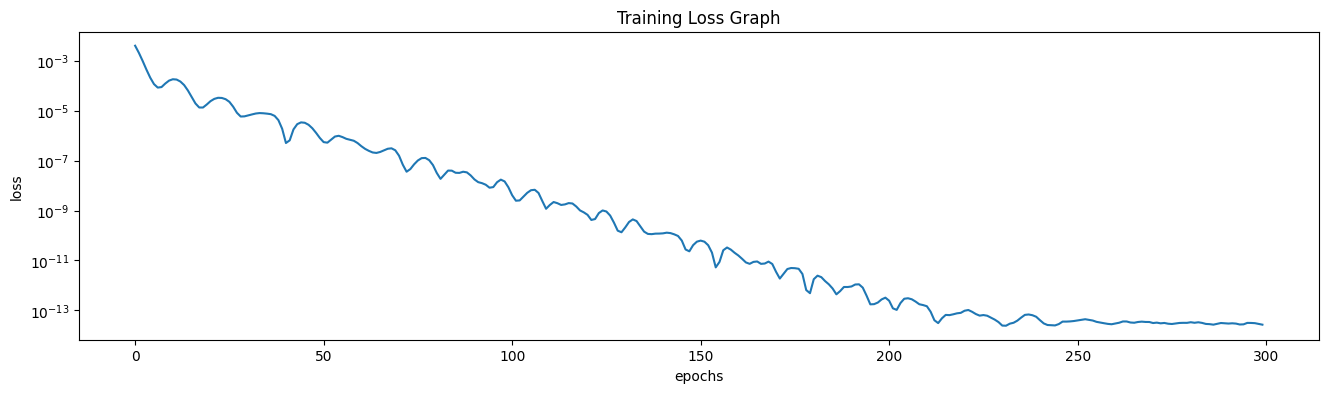

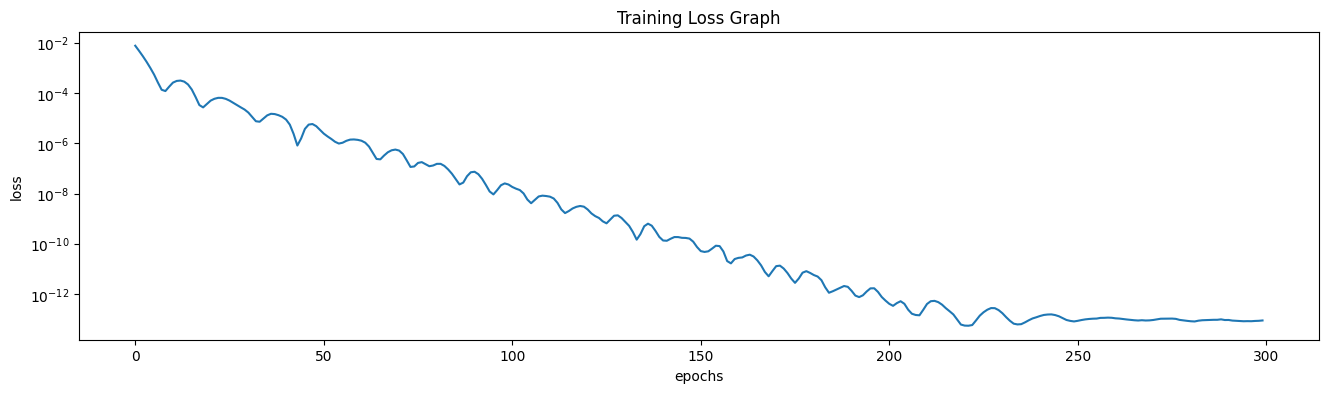

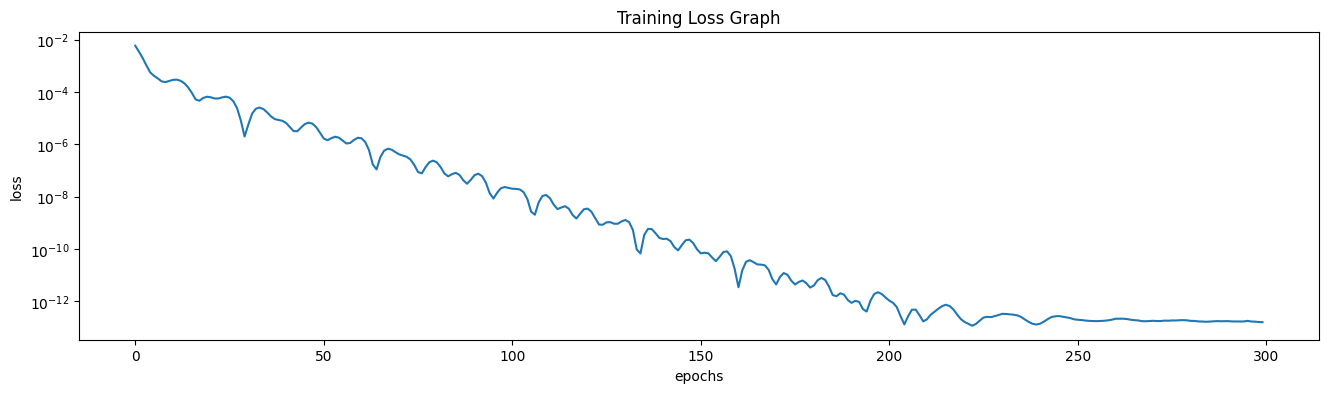

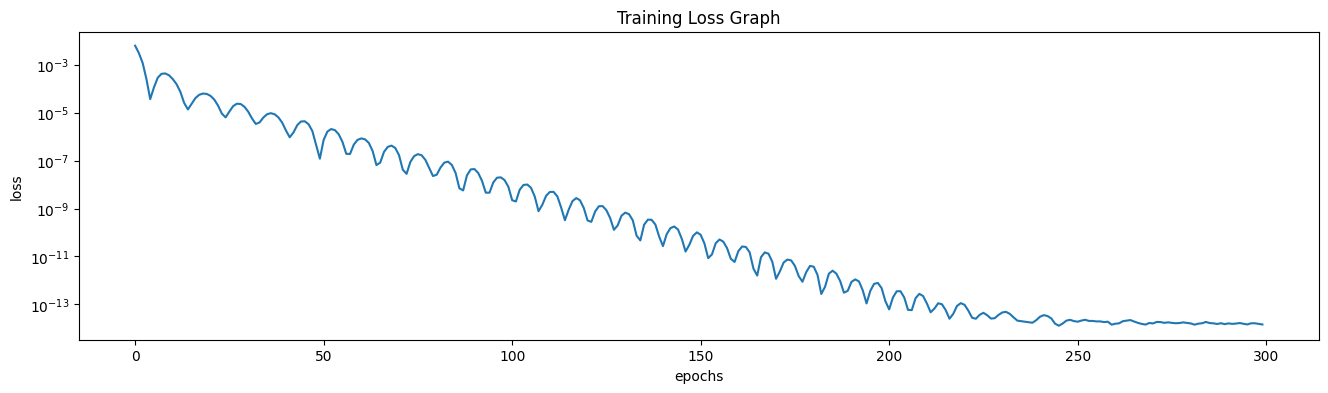

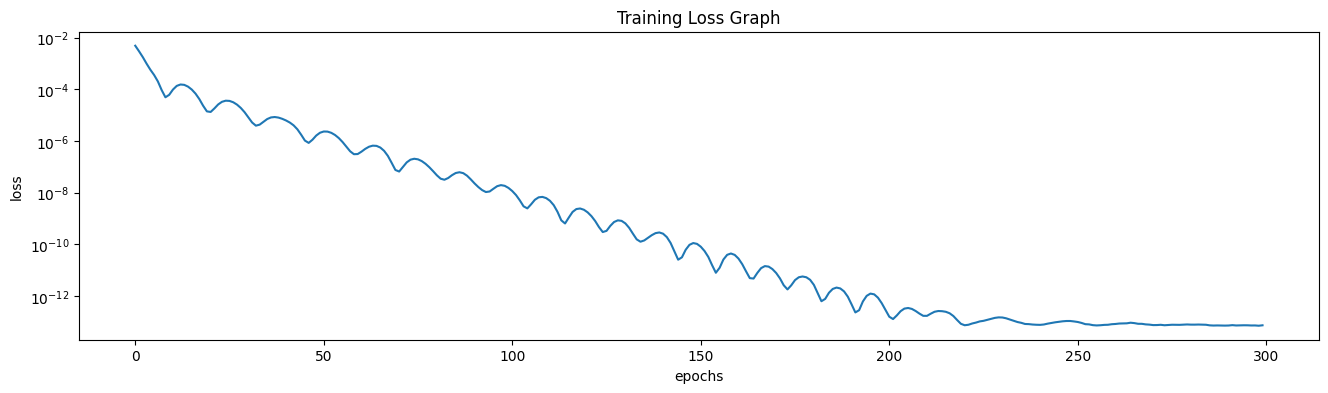

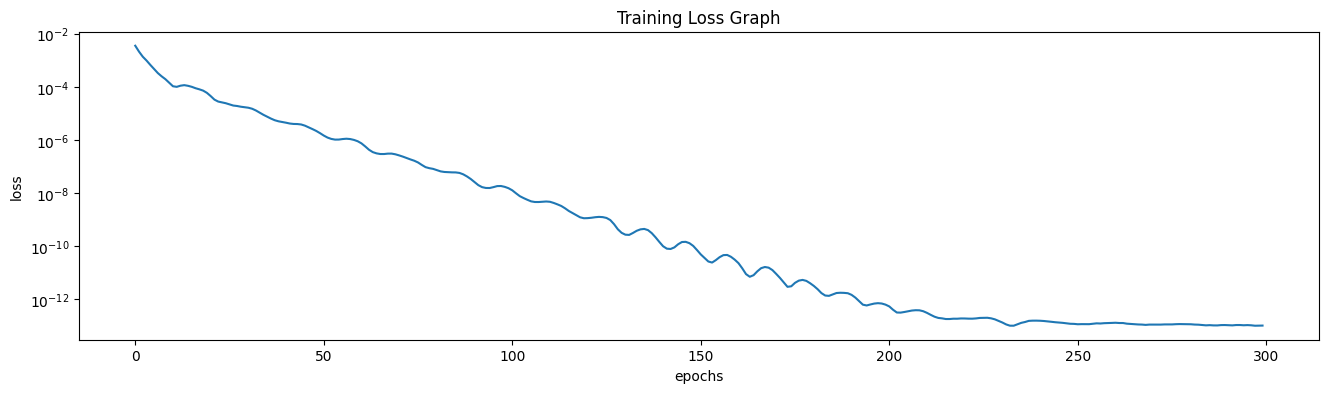

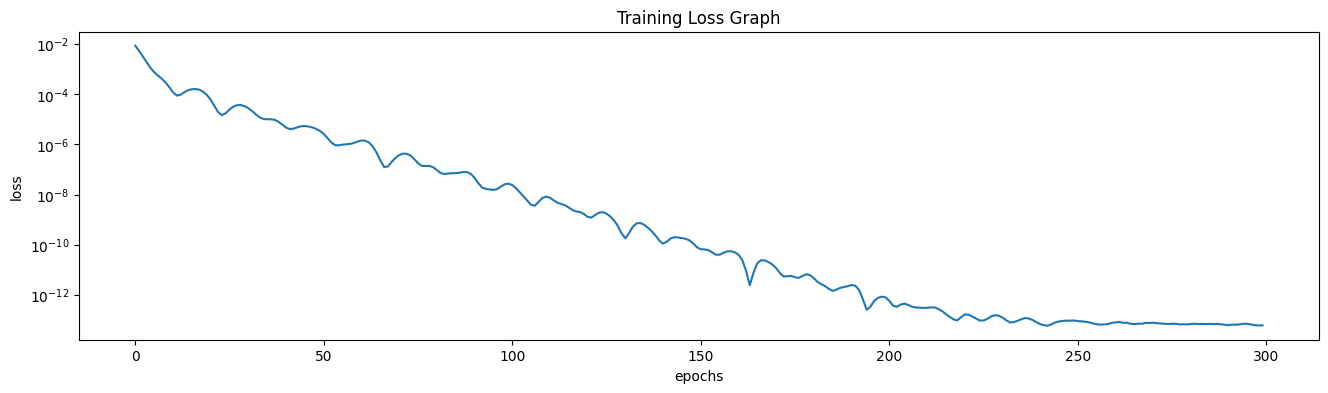

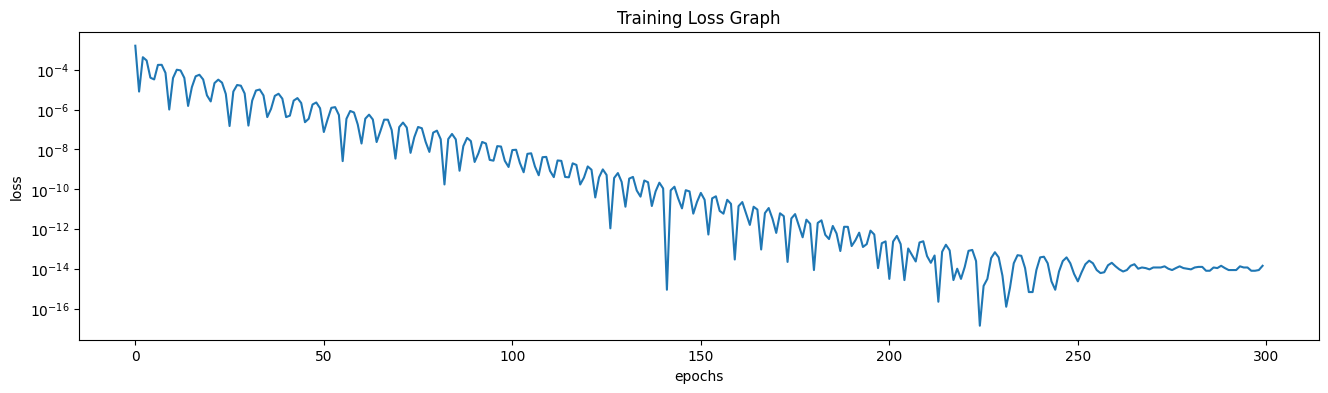

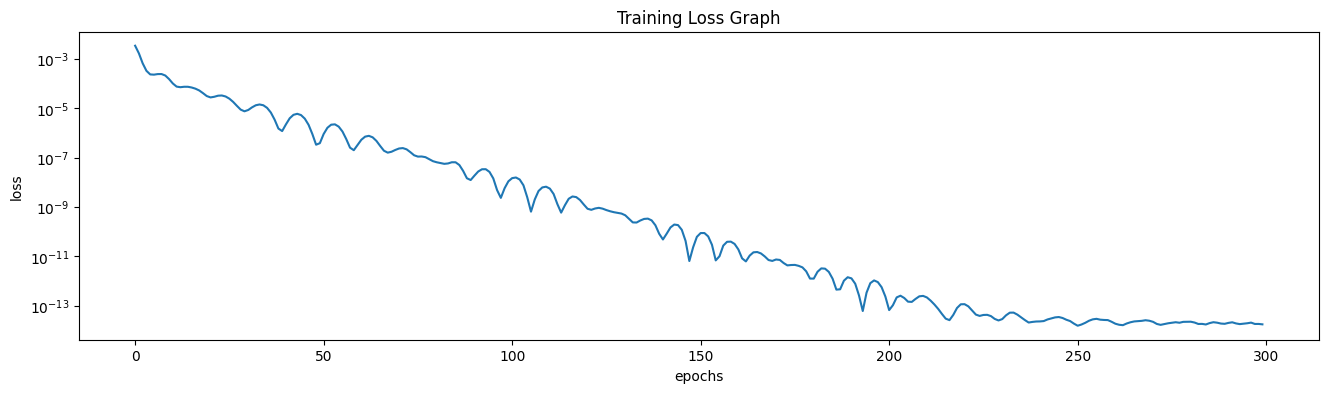

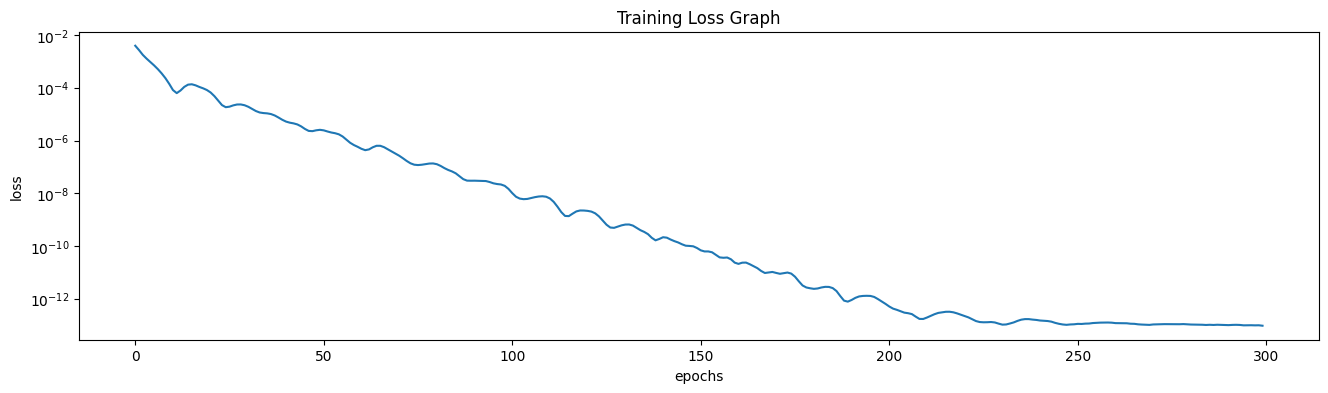

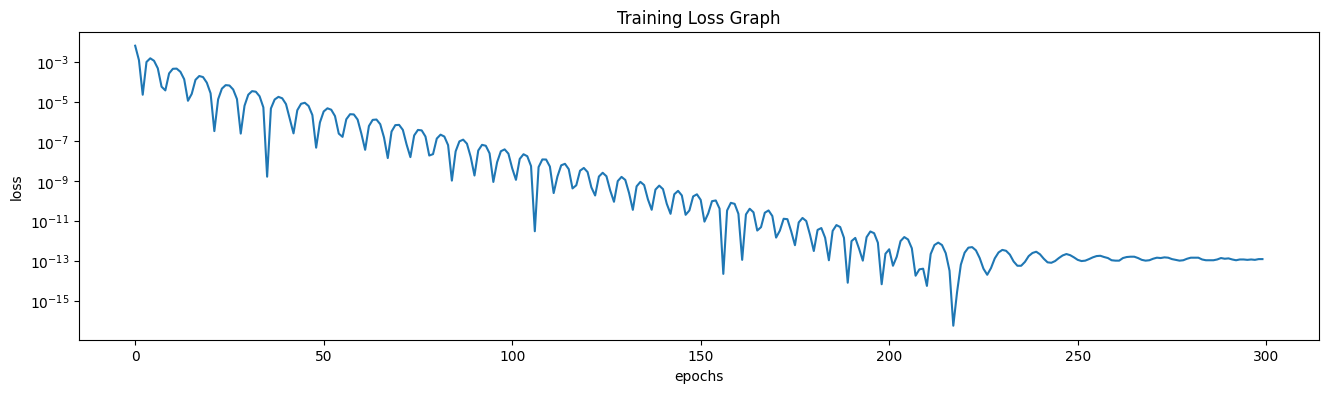

In [45]:
# 데이터 shuffle은 False 설정함
def train(dataset, model, batch_size, n_epochs):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    optimizer = torch.optim.AdamW(model.parameters())# ------------------- Check
#    loss_fn = torch.nn.L1Loss()# ------------------- Check
    loss_fn = torch.nn.MSELoss()# ------------------- Check
    epochs = trange(n_epochs, desc="training")
    best = {"loss": sys.float_info.max}
    loss_history = []
    for e in epochs:
        epoch_loss = 0
        for batch in dataloader:
            optimizer.zero_grad()
            given = batch["given"].to(device)
            guess = model(given).to(device)
            answer = batch["answer"].to(device)
            loss = loss_fn(answer, guess)
            loss.backward()
            epoch_loss += loss.item()
            optimizer.step()
        loss_history.append(epoch_loss)
        epochs.set_postfix_str(f"loss: {epoch_loss:.6f}")
        if epoch_loss < best["loss"]:
            best["state"] = model.state_dict()
            best["loss"] = epoch_loss
            best["epoch"] = e + 1
    return best, loss_history


def train_data():

  # Unique Arbitration_ID 리스트 생성
  dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
  modle_dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/Newmodel_data/'
  unique_file_name = f'unique_ids{0}.csv'

  unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})

  # Unique Arbitration_ID 리스트 생성
  # unique_ids = can_normal['Arbitration_ID'].unique()
  skipped = True

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for index,row in unique_ids_pd.iterrows():
    arb_id = row['Arbitration_ID']
    Filenum = f"Nid{arb_id}"


    if skipped == True:
      if arb_id == '52A':
        skipped = False
        print(f'arb_id {arb_id} is skipped')
        continue
      else:
        print(f'arb_id {arb_id} is skipped')
        continue

    # 파일명 생성
    normalized_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/NewNormalized_data'
    file_name = f'pre_train_D_0_ID_{arb_id}.csv'
    file_path = f'{normalized_path}/{file_name}'
    print(file_path)
    can_normal = pd.read_csv(file_path)

    DROP_FIELD = ["Timestamp", "Class0", "Class1"]
    TIMESTAMP_FIELD = "Timestamp"
    ATTACK_FIELD = "Class0"
    VALID_COLUMNS_IN_TRAIN_DATASET = can_normal.columns
    VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD)

    # Data Load & Merge
    TRAIN_DF_RAW = can_normal
    TRAIN_DF = TRAIN_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]

    CAN_DATASET_TRAIN = CANDataset(TRAIN_DF_RAW[TIMESTAMP_FIELD], TRAIN_DF, stride=1)

    MODEL = StackedGRU(n_tags=TRAIN_DF.shape[1])
    MODEL.to(device)

    # Find Best Model
    MODEL.train()
    BEST_MODEL, LOSS_HISTORY = train(CAN_DATASET_TRAIN, MODEL, BATCH_SIZE, EPOCH)
    BEST_MODEL["loss"], BEST_MODEL["epoch"]

    with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + "_" + str(N_HIDDENS) + "_" + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "wb") as f:
        torch.save(
            {
                "state": BEST_MODEL["state"],
                "loss_history": LOSS_HISTORY,
            },
            f,
        )
    with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + "_" + str(N_HIDDENS) + "_" + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
        SAVED_MODEL = torch.load(f)

    if device == 'cuda':
      torch.cuda.empty_cache()

    MODEL.load_state_dict(SAVED_MODEL["state"])

    plt.figure(figsize=(16, 4))
    plt.title("Training Loss Graph")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.yscale("log")
    plt.plot(SAVED_MODEL["loss_history"])
    plt.savefig(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_loss.png")
    with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_loss_history.txt", 'w') as f:
        with redirect_stdout(f):
            print(SAVED_MODEL["loss_history"])


    if device == 'cuda':
      torch.cuda.empty_cache()

    # del CAN_DATASET_TRAIN, CAN_DATASET_VALIDATION, CAN_DATASET_TEST

train_data()

###New Predict

arb_id = 356
NewNormalized_data/pre_train_D_1_ID_356.csv


  0%|          | 0/31136 [00:00<?, ?it/s]

# of valid windows: 31136
Validationdf : (31160, 4)
ATTACK_LABELS: 31160
CHECK_PRED: 31160
CHECK_DIST: 31160


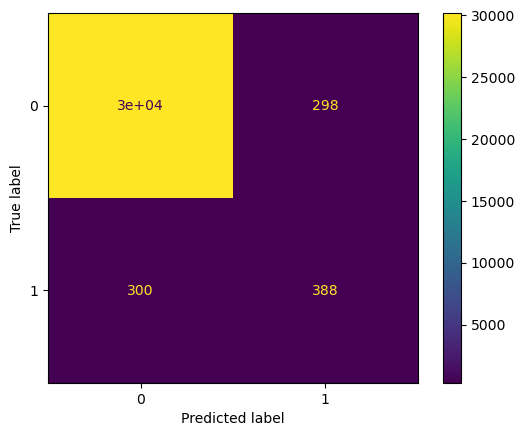

In [108]:
# weight = [0.211626213,0.232259096,0.09876504,0.000671909,0.000594123,0.000375021,0.001107795,0.000801762,0.000292301,0.999215865,0.331892907,0.386764656,0.350348024,0.49078898,0.44515159]
# weight = weight * 100
# weight = [np.min([1.0 / w, 1.0]) for w in weight]

def dist_norm(row, guess):
    # return LA.norm(torch.from_numpy(row.to_numpy()) - guess)
    return np.mean(np.abs(torch.from_numpy(row.to_numpy()) - guess).numpy(), axis=1)
    # return np.mean(np.pow(dis, 2))
    # return np.mean(dis, axis=1)

    # return np.mean(np.abs(torch.from_numpy(row.to_numpy()) - guess).numpy(), axis=1)

def predict(df, timestamps, model, time_span):
    answer_idxs = []
    valid_idxs = []
    pred = []
    dist = []
    last_time = 0;

    with torch.no_grad():
      ts = np.array(timestamps)
      tag_values = np.array(df, dtype=np.float32)
      for i in range(0, len(ts)):
        if(len(valid_idxs) < WINDOW_SIZE-1 ):
          valid_idxs.append(i)
          pred.append(0)
          dist.append(0)
          continue

        if ts[i] - ts[valid_idxs[WINDOW_SIZE-2]] < time_span :
          answer_idxs.append(i)
          pred.append(1) # default attack set
          continue

        else:
          single_record = torch.from_numpy(np.array(df.iloc[valid_idxs], dtype=np.float32))
          given = single_record.unsqueeze(0)

          guess = model(given)

          # eval
          # 시간 간격이 붕 떠서 time_span안에 하나도 없으면 다음 레코드를 정상으로 간주
          if len(answer_idxs) == 0:
            # cur_dists = answer.apply(distance_from_point, axis=1, point=guess)
            #cur_dist = LA.norm(torch.from_numpy(df.iloc[i].to_numpy()) - guess, axis=1)
            cur_dist = np.mean(torch.abs(torch.from_numpy(df.iloc[i].to_numpy()) - guess).numpy(), axis=1)

            dist.append(cur_dist)
            pred.append(0)
            valid_idxs.append(i) # valid index shift right
            valid_idxs.pop(0)
            continue

          if len(answer_idxs) > 1:
            answerdb = df.iloc[answer_idxs]
            tmpDist = answerdb.apply(dist_norm, axis=1, guess=guess).to_numpy()
            # cur_dist = tmpDist * weight
            # tmpDist = answerdb.apply(dist_norm, axis=1, guess=guess).to_numpy()
            min_idx = np.argmin(tmpDist)
            min_dis = tmpDist[min_idx]
            min_idx = answer_idxs[min_idx]
            dist.extend(np.array(tmpDist).reshape(-1))
          else:
            min_idx = answer_idxs[0]
            min_dis = np.mean(torch.abs(torch.from_numpy(df.iloc[min_idx].to_numpy()) - guess).numpy(), axis=1)
            #min_dis = LA.norm(torch.from_numpy(df.iloc[min_idx].to_numpy()) - guess, axis=1)
            dist.extend(np.array(min_dis).reshape(-1))


          if min_dis < 1.0:
            pred[min_idx] = 0  # to normal set
            valid_idxs.append(min_idx) # valid index shift right
            valid_idxs.pop(0)


          answer_idxs = []
          answer_idxs.append(i)
          pred.append(1) # default attack set

      pred[len(pred)-1] = 0
      dist.append(0)
    return (
        ts,
        pred,
        dist
    )

def predict_all():
    answer_idxs = []
    valid_idxs = []
    pred = []
    dist = []

    # Unique Arbitration_ID 리스트 생성
    dir_name = ''
    modle_dir_name = 'Newmodel_data/'
    normalized_path = 'NewNormalized_data'
    pred0_path = 'Newpred0_data'

    unique_file_name = f'unique_ids{0}.csv'

    unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
    unique_ids = unique_ids_pd['Arbitration_ID'].to_numpy()

    # Unique Arbitration_ID 리스트 생성
    # unique_ids = can_normal['Arbitration_ID'].unique()

    skipped = True
    # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
    for index, row in unique_ids_pd.iterrows():
      arb_id = row['Arbitration_ID']
      time_span = row['time_span']

      if arb_id != '356':
        # print(f'arb_id {arb_id} is skipped')
        continue

      # if skipped == True:
      #   if arb_id == '356':
      #     skipped = False
      #     print(f'arb_id {arb_id} is skipped')
      #     continue
      #   else:
      #     print(f'arb_id {arb_id} is skipped')
      #     continue
      # else:
      #   if arb_id == '391':
      #     skipped = True
      #     print(f'arb_id {arb_id} is skipped')
      #     continue
        

      print('arb_id = ' + str(arb_id))
      Filenum = f"Nid{arb_id}"

      # 파일명 생성
      file_name = f'pre_train_D_1_ID_{arb_id}.csv'
      file_path = f'{normalized_path}/{file_name}'
      print(file_path)
      can_val = pd.read_csv(file_path)

      DROP_FIELD = ["Timestamp", "Class0", "Class1"]
      TIMESTAMP_FIELD = "Timestamp"
      ATTACK_FIELD = "Class0"
      VALID_COLUMNS_IN_TRAIN_DATASET = can_val.columns
      VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD)

      # Data Load & Merge
      VALIDATION_DF_RAW = can_val
      VALIDATION_DF = VALIDATION_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]

      CAN_DATASET_VALIDATION = CANDataset(VALIDATION_DF_RAW[TIMESTAMP_FIELD], VALIDATION_DF, attacks=VALIDATION_DF_RAW[ATTACK_FIELD])

      # Model Load
      with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
          SAVED_MODEL = torch.load(f, map_location=torch.device(device))

      MODEL = StackedGRU(n_tags=VALIDATION_DF.shape[1])
      MODEL.load_state_dict(SAVED_MODEL["state"])

      MODEL.eval()

  # ts = np.array(VALIDATION_DF_RAW[TIMESTAMP_FIELD],)
  # tag_values = np.array(VALIDATION_DF, dtype=np.float32)

      CHECK_TS, CHECK_PRED, CHECK_DIST = predict(VALIDATION_DF, VALIDATION_DF_RAW[TIMESTAMP_FIELD], MODEL, time_span*1.51)
      ATTACK_LABELS = np.array(VALIDATION_DF_RAW["Class0"])

      print('Validationdf : ' + str(VALIDATION_DF.shape))
      print('ATTACK_LABELS: ' + str(ATTACK_LABELS.size))
      print('CHECK_PRED: ' + str(len(CHECK_PRED)))
      print('CHECK_DIST: ' + str(len(CHECK_DIST)))
      VALIDATION_DF_RAW["Dist"] = CHECK_DIST

      conf_mat = confusion_matrix(y_true=ATTACK_LABELS, y_pred=CHECK_PRED)
      conf_mat

      # confusion matrix 시각화
      disp = ConfusionMatrixDisplay(conf_mat)
      disp.plot()

      VALIDATION_DF_RAW["Pred0"] = CHECK_PRED
      file_path = f'{pred0_path}/{file_name}'
      VALIDATION_DF_RAW.to_csv(file_path, index=False)


predict_all()

### NewL1

arb_id = 260
drive/MyDrive/Colab Notebooks/CAN_IDS/NewNormalized_data/pre_train_D_0_ID_260.csv


  0%|          | 0/7442 [00:00<?, ?it/s]

# of valid windows: 7442
Validationdf : (7466, 15)
ATTACK_LABELS: 7466
CHECK_PRED: 7466
CHECK_DIST: 7466
arb_id 329 is skipped
arb_id 38D is skipped
arb_id 420 is skipped
arb_id 421 is skipped
arb_id 153 is skipped
arb_id 220 is skipped
arb_id 340 is skipped
arb_id 389 is skipped
arb_id 47F is skipped
arb_id 130 is skipped
arb_id 140 is skipped
arb_id 251 is skipped
arb_id 2B0 is skipped
arb_id 164 is skipped
arb_id 356 is skipped
arb_id 366 is skipped
arb_id 367 is skipped
arb_id 368 is skipped
arb_id 381 is skipped
arb_id 387 is skipped
arb_id 394 is skipped
arb_id 453 is skipped
arb_id 470 is skipped
arb_id 490 is skipped
arb_id 495 is skipped
arb_id 500 is skipped
arb_id 391 is skipped
arb_id 4F1 is skipped
arb_id 484 is skipped
arb_id 386 is skipped
arb_id 479 is skipped
arb_id 436 is skipped
arb_id 541 is skipped
arb_id 485 is skipped
arb_id 492 is skipped
arb_id 4C9 is skipped
arb_id 48A is skipped
arb_id 58B is skipped
arb_id 48C is skipped
arb_id 544 is skipped
arb_id 553 is s

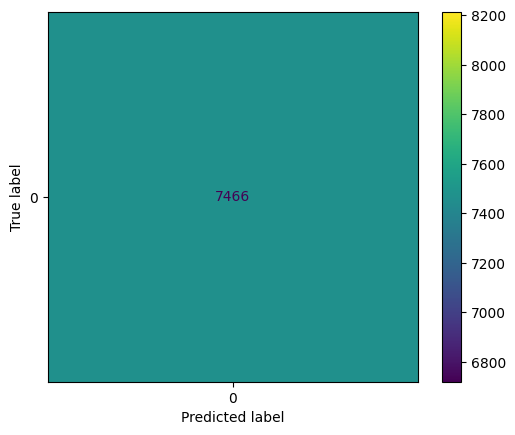

In [ ]:
def dist_norm(row, guess):
    return np.abs(torch.from_numpy(row.to_numpy()) - guess).numpy()

def predict(df, timestamps, model, time_span):
    answer_idxs = []
    valid_idxs = []
    pred = []
    dist = []
    size = len(df.columns)

    with torch.no_grad():
      ts = np.array(timestamps)
      tag_values = np.array(df, dtype=np.float32)
      for i in range(0, len(ts)):
        if(len(valid_idxs) < WINDOW_SIZE-1 ):
          valid_idxs.append(i)
          pred.append(0)
          dist.append(np.zeros(size))
          continue

        if ts[i] - ts[valid_idxs[WINDOW_SIZE-2]] < time_span :
          answer_idxs.append(i)
          pred.append(1) # default attack set
          continue

        else:
          single_record = torch.from_numpy(np.array(df.iloc[valid_idxs], dtype=np.float32))
          given = single_record.unsqueeze(0)

          # print(f'given len is {given.shape}')

          guess = model(given)

          # eval
          # 시간 간격이 붕 떠서 time_span안에 하나도 없으면 다음 레코드를 정상으로 간주
          if len(answer_idxs) == 0:
            # cur_dists = answer.apply(distance_from_point, axis=1, point=guess)
            # cur_dist = LA.norm(torch.from_numpy(df.iloc[i].to_numpy()) - guess, axis=1)
            cur_dist = torch.abs(torch.from_numpy(df.iloc[i].to_numpy()) - guess).numpy()
            # cur_dist = np.mean(torch.abs(torch.from_numpy(df.iloc[i].to_numpy()) - guess).numpy(), axis=1
            if cur_dist < 5:
              dist.extend(np.array(min_dis))
              pred.append(0)
              valid_idxs.append(i) # valid index shift right
              valid_idxs.pop(0)
              continue
            else:
              dist.append(np.zeros(size))
              pred.append(1) # default attack set
              continue

          if len(answer_idxs) > 1:
            answerdb = df.iloc[answer_idxs]
            tmpDist = answerdb.apply(dist_norm, axis=1, guess=guess).to_numpy()
            # tmpDist = answerdb.apply(dist_norm, axis=1, guess=guess).to_numpy()
            min_idx = np.argmin(np.mean(tmpDist, axis=1))
            min_dis = tmpDist[min_idx]
            min_idx = answer_idxs[min_idx]
            dist.extend(np.array(tmpDist.numpy()))
          else:
            min_dis = torch.abs(torch.from_numpy(df.iloc[answer_idxs[0]].to_numpy()) - guess).numpy()
            min_idx = answer_idxs[0]
            dist.extend(np.array(min_dis))

          pred[min_idx] = 0  # to normal set
          valid_idxs.append(min_idx) # valid index shift right
          valid_idxs.pop(0)

          # answer = torch.from_numpy(np.array(answerdb))
          # answer = torch.from_numpy(np.array(df.iloc[answer_idxs]))
          # min_dis = answerdb['Dist'].iloc[min_idx]


#           min_dis = 10000
#           idx = answer_idxs[0]
#           min_idx = idx
#           for itm in answer:
#             cur_dist = np.mean(torch.abs(itm - guess).numpy(), axis=1)
#             dist.append(cur_dist)
#             if min_dis > cur_dist:
#               min_dis = cur_dist
# #              min_dis = torch.abs(itm - guess).numpy()
#               min_idx = idx
#             idx = idx + 1

          # print(f'answer_idxs[0] is {answer_idxs[0]}')
          # print(f'pred.len is {len(pred)}')
          # print(f'min_idx is {min_idx}')

          answer_idxs = []
          answer_idxs.append(i)
          pred.append(1) # default attack set

      pred[len(pred)-1] = 0
      dist.append(np.zeros(size))
    return (
        ts,
        pred,
        dist
    )

def predict_all():
    answer_idxs = []
    valid_idxs = []
    pred = []
    dist = []

    # Unique Arbitration_ID 리스트 생성
    dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
    modle_dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/Newmodel_data/'
    normalized_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/NewNormalized_data'
    pred1_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/Newpred1_data'

    unique_file_name = f'unique_ids{0}.csv'

    unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
    unique_ids = unique_ids_pd['Arbitration_ID'].to_numpy()

    # Unique Arbitration_ID 리스트 생성
    # unique_ids = can_normal['Arbitration_ID'].unique()

    # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
    for index, row in unique_ids_pd.iterrows():
      arb_id = row['Arbitration_ID']
      time_span = row['time_span']

      if arb_id != '260':
        print(f'arb_id {arb_id} is skipped')
        continue

      print('arb_id = ' + str(arb_id))
      Filenum = f"Nid{arb_id}"

      # 파일명 생성
      file_name = f'pre_train_D_0_ID_{arb_id}.csv'
      file_path = f'{normalized_path}/{file_name}'
      print(file_path)
      can_val = pd.read_csv(file_path)

      DROP_FIELD = ["Timestamp", "Class0", "Class1"]
      TIMESTAMP_FIELD = "Timestamp"
      ATTACK_FIELD = "Class0"
      VALID_COLUMNS_IN_TRAIN_DATASET = can_val.columns
      VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD)

      # Data Load & Merge
      VALIDATION_DF_RAW = can_val
      VALIDATION_DF = VALIDATION_DF_RAW[VALID_COLUMNS_IN_TRAIN_DATASET]

      CAN_DATASET_VALIDATION = CANDataset(VALIDATION_DF_RAW[TIMESTAMP_FIELD], VALIDATION_DF, attacks=VALIDATION_DF_RAW[ATTACK_FIELD])

      # Model Load
      with open(modle_dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
          SAVED_MODEL = torch.load(f, map_location=torch.device(device))

      MODEL = StackedGRU(n_tags=VALIDATION_DF.shape[1])
      MODEL.load_state_dict(SAVED_MODEL["state"])

      MODEL.eval()

  # ts = np.array(VALIDATION_DF_RAW[TIMESTAMP_FIELD],)
  # tag_values = np.array(VALIDATION_DF, dtype=np.float32)

      CHECK_TS, CHECK_PRED, CHECK_DIST = predict(VALIDATION_DF, VALIDATION_DF_RAW[TIMESTAMP_FIELD], MODEL, time_span*1.6)
      ATTACK_LABELS = np.array(VALIDATION_DF_RAW["Class0"])

      print('Validationdf : ' + str(VALIDATION_DF.shape))
      print('ATTACK_LABELS: ' + str(ATTACK_LABELS.size))
      print('CHECK_PRED: ' + str(len(CHECK_PRED)))
      print('CHECK_DIST: ' + str(len(CHECK_DIST)))
      VALIDATION_DF_RAW["Dist"] = np.mean(np.abs(CHECK_DIST), axis=1)

      conf_mat = confusion_matrix(y_true=ATTACK_LABELS, y_pred=CHECK_PRED)
      conf_mat

      # confusion matrix 시각화
      disp = ConfusionMatrixDisplay(conf_mat)
      disp.plot()

      VALIDATION_DF_RAW["Pred0"] = CHECK_PRED
      file_path = f'{pred1_path}/{file_name}'
      VALIDATION_DF_RAW.to_csv(file_path, index=False)
      dist_df = pd.DataFrame(CHECK_DIST)
      file_name = f'pre_train_D_0_ID_{arb_id}_dist.csv'
      file_path = f'{pred1_path}/{file_name}'
      dist_df.to_csv(file_path, index=False)


predict_all()

##GRU Train

In [ ]:

# WINDOW_GIVEN_LIST 변수와 FOR문을 통해서 Window size가 다른 각 각의 모델을 생성하였음
# 모델의 THRESHOLD가 0.04 수준까지 되었을 때(오탐이 없는), 좋은 모델이라 판단하였음
# 즉, 1번의 모델생성으로 좋은 모델이 생성되기 어렵다.
# > 모든 seed를 고정시켜 테스팅하는 것은 많은 비용이 발생하기 때문에, 그리고 모델의 랜덤성을 주기 위해 반복적으로 모델을 생성하여 좋은 모델을 선택(각 모델이 상호 보완 될 수 있도록)하였음

#WINDOW_GIVEN_LIST = [29, 39, 49, 54, 59, 64, 69, 74, 79]
WINDOW_GIVEN_LIST = [49]
# Model Config
for i in range(len(WINDOW_GIVEN_LIST)):
    Filenum = "E(50)_"
    N_HIDDENS = 100 #
    N_LAYERS = 2 #
    EPOCH = 150 #
    #EPOCH = 1 #
    WINDOW_GIVEN = WINDOW_GIVEN_LIST[i]
    BATCH_SIZE = 1024
    WINDOW_SIZE = WINDOW_GIVEN + 1
    THRESHOLD = 0.2

    CAN_DATASET_TRAIN = CANDataset(TRAIN_DF_RAW[TIMESTAMP_FIELD], TRAIN_DF, stride=1)

    MODEL = StackedGRU(n_tags=TRAIN_DF.shape[1])
    MODEL.to(device)

    # Find Best Model
    MODEL.train()
    BEST_MODEL, LOSS_HISTORY = train(CAN_DATASET_TRAIN, MODEL, BATCH_SIZE, EPOCH)
    BEST_MODEL["loss"], BEST_MODEL["epoch"]

    with open(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + "_" + str(N_HIDDENS) + "_" + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "wb") as f:
        torch.save(
            {
                "state": BEST_MODEL["state"],
                "best_epoch": BEST_MODEL["epoch"],
                "loss_history": LOSS_HISTORY,
            },
            f,
        )
    with open(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + "_" + str(N_HIDDENS) + "_" + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
        SAVED_MODEL = torch.load(f)

    if device == 'cuda':
      torch.cuda.empty_cache()

    MODEL.load_state_dict(SAVED_MODEL["state"])

    plt.figure(figsize=(16, 4))
    plt.title("Training Loss Graph")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.yscale("log")
    plt.plot(SAVED_MODEL["loss_history"])
    plt.savefig(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_loss.png")
    with open(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_loss_history.txt", 'w') as f:
        with redirect_stdout(f):
            print(SAVED_MODEL["loss_history"])

# TRAIN SET 결과
    print('TRAIN SET 결과')
    # Model Load
    CAN_DATASET_TRAIN = CANDataset(TRAIN_DF_RAW[TIMESTAMP_FIELD], TRAIN_DF, attacks=None)

    with open(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
        SAVED_MODEL = torch.load(f)

    MODEL = StackedGRU(n_tags=TRAIN_DF.shape[1])
    MODEL.load_state_dict(SAVED_MODEL["state"])
    if device == 'cuda':
      MODEL.to(torch.device("cuda")) # use GPU

    MODEL.eval()
    CHECK_TS, CHECK_DIST, CHECK_ATT = inference(CAN_DATASET_TRAIN, MODEL, BATCH_SIZE)

    ANOMALY_SCORE = np.mean(CHECK_DIST, axis=1)
    check_graph(ANOMALY_SCORE, CHECK_ATT, piece=2, THRESHOLD=THRESHOLD, Switch=2)
    LABELS = put_labels(ANOMALY_SCORE, THRESHOLD)
    LABELS, LABELS.shape
    # ANOMALY_SCORE_DIST = np.power(np.mean(np.power(CHECK_DIST,2), axis=1), 0.5)
    # check_graph(ANOMALY_SCORE_DIST, CHECK_ATT, piece=2, THRESHOLD=THRESHOLD, Switch=1)
    # LABELS = put_labels(ANOMALY_SCORE_DIST, THRESHOLD)
    # LABELS, LABELS.shape

    # submission = pd.read_csv('data/HAI 2.0/sample_submission.csv') # ------------------ Check
    # submission.index = submission['time']
    # submission.loc[CHECK_TS,'attack'] = LABELS
    # submission
    # submission.to_csv(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + '_'+ str(THRESHOLD) + '_baseline.csv', index=False)

    if device == 'cuda':
      torch.cuda.empty_cache()

# VALIDATION SET 결과
    print('VALIDATION SET 결과')
    # Validation Check
    CAN_DATASET_VALIDATION = CANDataset(VALIDATION_DF_RAW[TIMESTAMP_FIELD], VALIDATION_DF, attacks=VALIDATION_DF_RAW[ATTACK_FIELD])

    # Model Load
    with open(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
        SAVED_MODEL = torch.load(f)

    MODEL = StackedGRU(n_tags=TRAIN_DF.shape[1])
    MODEL.load_state_dict(SAVED_MODEL["state"])
    if device == 'cuda':
      MODEL.to(torch.device("cuda")) # use GPU

    MODEL.eval()
    CHECK_TS, CHECK_DIST, CHECK_ATT = inference(CAN_DATASET_VALIDATION, MODEL, BATCH_SIZE)


    ANOMALY_SCORE = np.mean(CHECK_DIST, axis=1)
    check_graph(ANOMALY_SCORE, CHECK_ATT, piece=3, THRESHOLD=THRESHOLD, Switch=1)

    LABELS = put_labels(ANOMALY_SCORE, THRESHOLD)
    LABELS, LABELS.shape

    # ANOMALY_SCORE_DIST = np.power(np.mean(np.power(CHECK_DIST,2), axis=1), 0.5)
    # check_graph(ANOMALY_SCORE_DIST, CHECK_ATT, piece=3, THRESHOLD=THRESHOLD, Switch=1)

    # LABELS = put_labels(ANOMALY_SCORE_DIST, THRESHOLD)
    # LABELS, LABELS.shape

    ATTACK_LABELS = put_labels(np.array(VALIDATION_DF_RAW[ATTACK_FIELD]), threshold=0.5)
    ATTACK_LABELS, ATTACK_LABELS.shape

    FINAL_LABELS = fill_blank(CHECK_TS, LABELS, np.array(VALIDATION_DF_RAW[TIMESTAMP_FIELD]))
    FINAL_LABELS.shape

    conf_mat = confusion_matrix(y_true=ATTACK_LABELS, y_pred=FINAL_LABELS)
    conf_mat

    # confusion matrix 시각화
    disp = ConfusionMatrixDisplay(conf_mat)
    disp.plot()

    print(ATTACK_LABELS == FINAL_LABELS)
    print(ATTACK_LABELS.sum())
    print(FINAL_LABELS.sum())
    print(ATTACK_LABELS.shape)

    # 검증데이터 평가결과 저장
    # TaPR = etapr.evaluate(anomalies=ATTACK_LABELS, predictions=FINAL_LABELS)
    # with open(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + '_'+ str(THRESHOLD) + '_evaluation.txt', 'w') as f:
    #     with redirect_stdout(f):
    #         print(f"F1: {TaPR['f1']:.3f} (TaP: {TaPR['TaP']:.3f}, TaR: {TaPR['TaR']:.3f})")
    #         print(f"# of detected anomalies: {len(TaPR['Detected_Anomalies'])}")
    #         print(f"Detected anomalies: {TaPR['Detected_Anomalies']}")

    if device == 'cuda':
      torch.cuda.empty_cache()



# TEST SET 결과
    print('TEST SET 결과')
    # Model Load
    CAN_DATASET_TEST = CANDataset(TEST_DF_RAW[TIMESTAMP_FIELD], TEST_DF, attacks=None)

    with open(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + "_model.pt", "rb") as f:
        SAVED_MODEL = torch.load(f)

    MODEL = StackedGRU(n_tags=TRAIN_DF.shape[1])
    MODEL.load_state_dict(SAVED_MODEL["state"])

    if device == 'cuda':
          MODEL.to(torch.device("cuda")) # use GPU

    MODEL.eval()
    CHECK_TS, CHECK_DIST, CHECK_ATT = inference(CAN_DATASET_TEST, MODEL, BATCH_SIZE)

    ANOMALY_SCORE = np.mean(CHECK_DIST, axis=1)
    check_graph(ANOMALY_SCORE, CHECK_ATT, piece=2, THRESHOLD=THRESHOLD, Switch=2)
    LABELS = put_labels(ANOMALY_SCORE, THRESHOLD)
    LABELS, LABELS.shape
    # ANOMALY_SCORE_DIST = np.power(np.mean(np.power(CHECK_DIST,2), axis=1), 0.5)
    # check_graph(ANOMALY_SCORE_DIST, CHECK_ATT, piece=2, THRESHOLD=THRESHOLD, Switch=1)
    # LABELS = put_labels(ANOMALY_SCORE_DIST, THRESHOLD)
    # LABELS, LABELS.shape

    # submission = pd.read_csv('data/HAI 2.0/sample_submission.csv') # ------------------ Check
    # submission.index = submission['time']
    # submission.loc[CHECK_TS,'attack'] = LABELS
    # submission
    # submission.to_csv(dir_name + str(Filenum) + '_' + str(WINDOW_GIVEN) + '_' + str(N_HIDDENS) + '_' + str(N_LAYERS) + '_' + str(BATCH_SIZE) + '_'+ str(THRESHOLD) + '_baseline.csv', index=False)

    if device == 'cuda':
      torch.cuda.empty_cache()

    # del CAN_DATASET_TRAIN, CAN_DATASET_VALIDATION, CAN_DATASET_TEST

NameError: name 'CANDataset' is not defined

In [ ]:
WINDOW_SIZE

50

In [ ]:
VALIDATION_DF.shape

NameError: name 'VALIDATION_DF' is not defined

In [ ]:
len(CHECK_DIST)
CHECK_DIST.append(0)

1177
1170
(31638,)


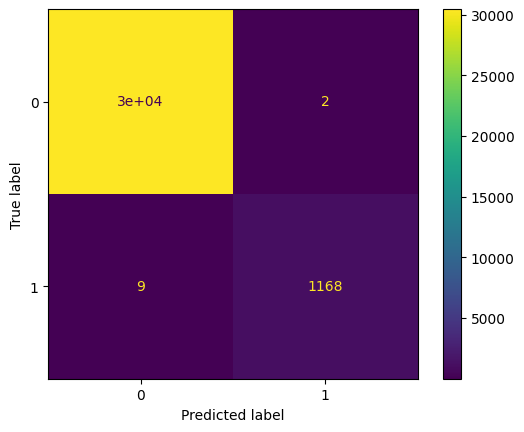

In [ ]:
attacks_map1 ={'Normal': 0, 'Fuzzing': 1, 'Replay': 1, 'Spoofing': 1, 'Flooding': 1}
VALIDATION_DF_RAW["Class1"] = VALIDATION_DF_RAW["SubClass"].map(attacks_map1)
ATTACK_LABELS = np.array(VALIDATION_DF_RAW["Class1"])
VALIDATION_DF_RAW["Dist"] = CHECK_DIST

conf_mat = confusion_matrix(y_true=ATTACK_LABELS, y_pred=CHECK_PRED)
conf_mat

# confusion matrix 시각화
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot()

print(ATTACK_LABELS.sum())
print(sum(CHECK_PRED))
print(ATTACK_LABELS.shape)

file_name = f'pre_train_D_1_ID_366.csv'
file_path = f'{save_path}/{file_name}'

VALIDATION_DF_RAW["Class1"] = CHECK_PRED
VALIDATION_DF_RAW.to_csv(file_path, index=False)

In [ ]:
VALIDATION_DF_RAW["Class1"] = CHECK_PRED

0.00037929072634174094

In [ ]:
fruits = ['apple', 'banana', 'cherry']


print(fruits[2])

cherry


In [ ]:
WINDOW_GIVEN = 29
WINDOW_SIZE= 30

def CANDataset(timestamps, df, stride=1, attacks=None):
    ts= np.array(timestamps)
    tag_values=np.array(df,dtype=np.float32)
    valid_idxs=[]
    for L in trange(len(ts)-WINDOW_SIZE+1):
        R = L + WINDOW_SIZE - 1
        if dateutil.parser.parse(ts[R]) - dateutil.parser.parse(ts[L]) == timedelta(seconds=WINDOW_SIZE - 1):
            valid_idxs.append(L)
    valid_idxs=np.array(valid_idxs, dtype=np.int32)[::stride]
    n_idxs = len(valid_idxs)
    print("# of valid windows:", n_idxs)
    if attacks is not None:
        attacks = np.array(attacks, dtype=np.float32)
        with_attack = True
    else:
        with_attack = False


    timestamp, X, y, att = list(), list(), list(), list()

    if with_attack:
        for i in valid_idxs:
            last=i+WINDOW_SIZE-1
            seq_time, seq_x, seq_y, seq_attack = ts[last], tag_values[i:i+WINDOW_GIVEN], tag_values[last], attacks[last]
            timestamp.append(seq_time)
            X.append(seq_x)
            y.append(seq_y)
            att.append(seq_attack)

        return np.array(timestamp), np.array(X), np.array(y), np.array(att)
    else:
        for i in valid_idxs:
            last=i+WINDOW_SIZE-1
            seq_time, seq_x, seq_y = ts[last], tag_values[i:i+WINDOW_GIVEN], tag_values[last]
            timestamp.append(seq_time)
            X.append(seq_x)
            y.append(seq_y)
        return np.array(timestamp), np.array(X), np.array(y)

In [ ]:
import can
import cantools
from pprint import pprint

db = cantools.database.load_file('drive/MyDrive/Colab Notebooks/CAN_IDS/hyundai_kia_generic.dbc')

dir_name = 'drive/MyDrive/Colab Notebooks/CAN_IDS/'
# 저장할 경로 설정 (예: 'My Drive/filtered_data')
save_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data'

def decode_can_message(row):
    try:
        decoded_message = db.decode_message(row['Hex_ID'], row['Hex_Data'])
        return decoded_message
    except Exception as e:
        return str(e)

for i in range(3):
  data_file_name = f'Pre_train_D_{i}'
  # decoded_file_name = f'{dir_name}{data_file_name}_ID_{arb_id}.csv'
  can_normal = pd.read_csv(f'{dir_name}{data_file_name}.csv')
  #can_normal = pd.read_csv('drive/MyDrive/Colab Notebooks/CAN_IDS/Pre_train_D_0.csv')
  data_columns = ['D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']
  can_normal[data_columns[:8]] = can_normal['Data'].str.split(expand=True).iloc[:, :8]

  can_normal['Hex_ID'] = can_normal['Arbitration_ID'][:].apply(int,base=16)
  can_normal['Hex_Data'] = can_normal['Data'][:].apply(bytes.fromhex)
  can_normal['Decoded'] = can_normal.apply(decode_can_message, axis=1)

  # Unique Arbitration_ID 리스트 생성
  unique_ids = can_normal['Arbitration_ID'].unique()

  saved_file_count = 0  # 저장된 파일의 개수를 세기 위한 변수
  no_decoded_count = 0  # 분석되지 않은 ID의 개수를 세기 위한 변수
  no_decoded_ids = []  # 분석되지 않은 ID를 저장할 리스트

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for arb_id in unique_ids:
      select_db = can_normal[can_normal['Arbitration_ID'] == arb_id]

      # decoded_message_example = {
      #     'TQI_MIN': 2.34375,
      #     'TQI': 14.453125,
      #     'TQI_TARGET': 1.953125,
      #     'GLOW_STAT': 0,
      #     'CRUISE_LAMP_M': 0,
      #     'CRUISE_LAMP_S': 0,
      #     'PRE_FUEL_CUT_IN': 0,
      #     'ENG_STAT': 3,
      #     'SOAK_TIME_ERROR': 0,
      #     'SOAK_TIME': 255,
      #     'TQI_MAX': 80.859375,
      #     'SPK_TIME_CUR': 6.75,
      #     'Checksum': 5,
      #     'AliveCounter': 1,
      #     'CF_Ems_AclAct': 1
      # }
      decoded_message_example = select_db['Decoded'].values[0]
      print(arb_id)
      print(decoded_message_example)

      # 파일명 생성
      file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
      file_path = f'{save_path}/{file_name}'

      if type(decoded_message_example) is not dict:
        no_decoded_count += 1
        no_decoded_ids.append(arb_id)
        # CSV 파일로 저장
        select_db.to_csv(file_path, index=False)
        continue

      # Decoded_Message 딕셔너리를 각각의 컬럼으로 확장
      for key in decoded_message_example.keys():
          select_db.loc[:, key] = select_db['Decoded'].apply(lambda x: x.get(key) if isinstance(x, dict) else None)

      # CSV 파일로 저장
      select_db.to_csv(file_path, index=False)
      print(f'{file_name} 저장 완료')
      saved_file_count += 1

  print(f"총 {saved_file_count}개의 파일이 저장되었습니다.")
  print(f"총 {no_decoded_count}개의 ID가 분석되지 않았습니다.")
  print(f"분석되지 않은 ID 목록:   {no_decoded_ids} ")

  for arb_id in no_decoded_ids:
      select_db = can_normal[can_normal['Arbitration_ID'] == arb_id][[]]

      # decoded_message_example = {
      #     'TQI_MIN': 2.34375,
      #     'TQI': 14.453125,
      #     'TQI_TARGET': 1.953125,
      #     'GLOW_STAT': 0,
      #     'CRUISE_LAMP_M': 0,
      #     'CRUISE_LAMP_S': 0,
      #     'PRE_FUEL_CUT_IN': 0,
      #     'ENG_STAT': 3,
      #     'SOAK_TIME_ERROR': 0,
      #     'SOAK_TIME': 255,
      #     'TQI_MAX': 80.859375,
      #     'SPK_TIME_CUR': 6.75,
      #     'Checksum': 5,
      #     'AliveCounter': 1,
      #     'CF_Ems_AclAct': 1
      # }
      decoded_message_example = select_db['Decoded'].values[0]
      print(arb_id)
      print(decoded_message_example)

      if type(decoded_message_example) is not dict:
        no_decoded_count += 1
        no_decoded_ids.append(arb_id)
        continue

      # Decoded_Message 딕셔너리를 각각의 컬럼으로 확장
      for key in decoded_message_example.keys():
          select_db.loc[:, key] = select_db['Decoded'].apply(lambda x: x.get(key) if isinstance(x, dict) else None)

      # 파일명 생성
      file_name = f'pre_train_D_{i}_ID_{arb_id}.csv'
      file_path = f'{save_path}/{file_name}'

      # CSV 파일로 저장
      select_db.to_csv(file_path, index=False)
      print(f'{file_name} 저장 완료')
      saved_file_count += 1

In [ ]:
import can
import cantools
from pprint import pprint

db = cantools.database.load_file('drive/MyDrive/Colab Notebooks/CAN_IDS/hyundai_kia_generic.dbc')

# 저장할 경로 설정 (예: 'My Drive/filtered_data')
save_path = 'drive/MyDrive/Colab Notebooks/CAN_IDS/decoded_data'

# CAN 메시지를 디코딩하는 함수
def decode_can_message(row):
    try:
        decoded_message = db.decode_message(row['Hex_ID'], row['Hex_Data'])
        return decoded_message
    except Exception as e:
        return str(e)

can_normal['Hex_ID'] = can_normal['Arbitration_ID'][:].apply(int,base=16)
can_normal['Hex_Data'] = can_normal['Data'][:].apply(bytes.fromhex)

# 데이터프레임의 각 행에 대해 디코딩을 수행하여 새로운 컬럼에 결과 추가
can_normal['Decoded'] = can_normal.apply(decode_can_message, axis=1)


# Unique Arbitration_ID 리스트 생성
unique_ids = can_normal['Arbitration_ID'].unique()

saved_file_count = 0  # 저장된 파일의 개수를 세기 위한 변수
no_decoded_count = 0  # 분석되지 않은 ID의 개수를 세기 위한 변수
no_decoded_ids = []  # 분석되지 않은 ID를 저장할 리스트

# 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
for arb_id in unique_ids:
    select_db = can_normal[can_normal['Arbitration_ID'] == arb_id]

    # decoded_message_example = {
    #     'TQI_MIN': 2.34375,
    #     'TQI': 14.453125,
    #     'TQI_TARGET': 1.953125,
    #     'GLOW_STAT': 0,
    #     'CRUISE_LAMP_M': 0,
    #     'CRUISE_LAMP_S': 0,
    #     'PRE_FUEL_CUT_IN': 0,
    #     'ENG_STAT': 3,
    #     'SOAK_TIME_ERROR': 0,
    #     'SOAK_TIME': 255,
    #     'TQI_MAX': 80.859375,
    #     'SPK_TIME_CUR': 6.75,
    #     'Checksum': 5,
    #     'AliveCounter': 1,
    #     'CF_Ems_AclAct': 1
    # }
    decoded_message_example = select_db['Decoded'].values[0]
    print(arb_id)
    print(decoded_message_example)

    if type(decoded_message_example) is not dict:
      no_decoded_count += 1
      no_decoded_ids.append(arb_id)
      continue

    # Decoded_Message 딕셔너리를 각각의 컬럼으로 확장
    for key in decoded_message_example.keys():
        select_db.loc[:, key] = select_db['Decoded'].apply(lambda x: x.get(key) if isinstance(x, dict) else None)

    # 파일명 생성
    file_name = f'pre_train_D_0_ID_{arb_id}.csv'
    file_path = f'{save_path}/{file_name}'

    # CSV 파일로 저장
    select_db.to_csv(file_path, index=False)
    print(f'{file_name} 저장 완료')
    saved_file_count += 1

print(f"총 {saved_file_count}개의 파일이 저장되었습니다.")
print(f"총 {no_decoded_count}개의 ID가 분석되지 않았습니다.")
print(f"분석되지 않은 ID 목록:   {no_decoded_ids} ")


260
{'TQI_MIN': 2.34375, 'TQI': 14.453125, 'TQI_TARGET': 1.953125, 'GLOW_STAT': 0, 'CRUISE_LAMP_M': 0, 'CRUISE_LAMP_S': 0, 'PRE_FUEL_CUT_IN': 0, 'ENG_STAT': 3, 'SOAK_TIME_ERROR': 0, 'SOAK_TIME': 255, 'TQI_MAX': 80.859375, 'SPK_TIME_CUR': 6.75, 'Checksum': 5, 'AliveCounter': 1, 'CF_Ems_AclAct': 1}
pre_train_D_0_ID_260.csv 저장 완료
329
{'MUL_CODE': 1, 'TEMP_ENG': 99.75, 'MAF_FAC_ALTI_MMV': 0.98406, 'VB_OFF_ACT': 0, 'ACK_ES': 0, 'CONF_MIL_FMY': 3, 'OD_OFF_REQ': 0, 'ACC_ACT': 0, 'CLU_ACK': 1, 'BRAKE_ACT': 1, 'ENG_CHR': 12, 'GP_CTL': 0, 'TPS': 6.103287799999999, 'PV_AV_CAN': 0.3906, 'ENG_VOL': 1.6, 'CONF_TCU': 10}
pre_train_D_0_ID_329.csv 저장 완료
38D
{'CF_VSM_Prefill': 0, 'CF_VSM_HBACmd': 0, 'CF_VSM_Warn': 0, 'CF_VSM_BeltCmd': 0, 'CR_VSM_DecCmd': 0.0, 'PAINT1_Status': 1, 'FCA_Status': 2, 'FCA_CmdAct': 0, 'FCA_StopReq': 0, 'FCA_DrvSetStatus': 1, 'CF_VSM_DecCmdAct': 0, 'FCA_Failinfo': 0, 'CR_FCA_Alive': 2, 'FCA_RelativeVelocity': 0.0, 'FCA_TimetoCollision': 2540, 'CR_FCA_ChkSum': 1}
pre_train_D_0_

In [ ]:
can_normal['Hex_ID'].values

array([ 608,  809,  909, ..., 1057,  304,  320])

In [ ]:
import can
import cantools
from pprint import pprint

db = cantools.database.load_file('drive/MyDrive/Colab Notebooks/CAN_IDS/hyundai_kia_generic.dbc')

#ArbIDs = int_val['Arbitration_ID'].values().toArray()

#db.decode_message(1057, data = bytes.fromhex('FE 07 00 FF E3 7F 00 52'))
#db.decode_message(can_normal['Hex_ID'].values, data = can_normal['Hex_Data'].values)

# CAN 메시지를 디코딩하는 함수
def decode_can_message(row):
    try:
        decoded_message = db.decode_message(row['Hex_ID'], row['Hex_Data'])
        return decoded_message
    except Exception as e:
        return str(e)

# 데이터프레임의 각 행에 대해 디코딩을 수행하여 새로운 컬럼에 결과 추가
can_normal['Decoded'] = can_normal.apply(decode_can_message, axis=1)




In [ ]:
db_decode.head()

,0
0,"{'TQI_MIN': 2.34375, 'TQI': 14.453125, 'TQI_TARGET': 1.953125, 'GLOW_STAT': 0, 'CRUISE_LAMP_M': 0, 'CRUISE_LAMP_S': 0, 'PRE_FUEL_CUT_IN': 0, 'ENG_STAT': 3, 'SOAK_TIME_ERROR': 0, 'SOAK_TIME': 255, 'TQI_MAX': 80.859375, 'SPK_TIME_CUR': 6.75, 'Checksum': 5, 'AliveCounter': 1, 'CF_Ems_AclAct': 1}"
1,"{'MUL_CODE': 1, 'TEMP_ENG': 99.75, 'MAF_FAC_ALTI_MMV': 0.98406, 'VB_OFF_ACT': 0, 'ACK_ES': 0, 'CONF_MIL_FMY': 3, 'OD_OFF_REQ': 0, 'ACC_ACT': 0, 'CLU_ACK': 1, 'BRAKE_ACT': 1, 'ENG_CHR': 12, 'GP_CTL': 0, 'TPS': 6.103287799999999, 'PV_AV_CAN': 0.3906, 'ENG_VOL': 1.6, 'CONF_TCU': 10}"
2,"{'CF_VSM_Prefill': 0, 'CF_VSM_HBACmd': 0, 'CF_VSM_Warn': 0, 'CF_VSM_BeltCmd': 0, 'CR_VSM_DecCmd': 0.0, 'PAINT1_Status': 1, 'FCA_Status': 2, 'FCA_CmdAct': 0, 'FCA_StopReq': 0, 'FCA_DrvSetStatus': 1, 'CF_VSM_DecCmdAct': 0, 'FCA_Failinfo': 0, 'CR_FCA_Alive': 2, 'FCA_RelativeVelocity': 0.0, 'FCA_TimetoCollision': 2540, 'CR_FCA_ChkSum': 1}"
3,"{'MainMode_ACC': 0, 'SCCInfoDisplay': No Message, 'AliveCounterACC': 5, 'VSetDis': 30, 'ObjValid': 0, 'DriverAlertDisplay': 0, 'TauGapSet': 0, 'ACC_ObjStatus': 0, 'ACC_ObjLatPos': 0.0, 'ACC_ObjDist': 204.60000000000002, 'ACC_ObjRelSpd': 0.0, 'Navi_SCC_Curve_Status': 0, 'Navi_SCC_Curve_Act': 0, 'Navi_SCC_Camera_Act': 0, 'Navi_SCC_Camera_Status': 0}"
4,"{'CF_VSM_Prefill': 0, 'CF_VSM_DecCmdAct': 1, 'CF_VSM_HBACmd': 3, 'CF_VSM_Warn': 3, 'CF_VSM_Stat': 3, 'CF_VSM_BeltCmd': 7, 'ACCFailInfo': 0, 'ACCMode': off, 'StopReq': 0, 'CR_VSM_DecCmd': 0.0, 'aReqRaw': 0.0, 'TakeOverReq': 0, 'PreFill': 0, 'aReqValue': 0.0, 'CF_VSM_ConfMode': 0, 'AEB_Failinfo': 0, 'AEB_Status': 0, 'AEB_CmdAct': 0, 'AEB_StopReq': 0, 'CR_VSM_Alive': 2, 'CR_VSM_ChkSum': 5}"


In [ ]:
# 예제 Decoded_Message 데이터를 갖고 있는 딕셔너리
decoded_message_example = {
    'TQI_MIN': 2.34375,
    'TQI': 14.453125,
    'TQI_TARGET': 1.953125,
    'GLOW_STAT': 0,
    'CRUISE_LAMP_M': 0,
    'CRUISE_LAMP_S': 0,
    'PRE_FUEL_CUT_IN': 0,
    'ENG_STAT': 3,
    'SOAK_TIME_ERROR': 0,
    'SOAK_TIME': 255,
    'TQI_MAX': 80.859375,
    'SPK_TIME_CUR': 6.75,
    'Checksum': 5,
    'AliveCounter': 1,
    'CF_Ems_AclAct': 1
}

# Decoded_Message 딕셔너리를 각각의 컬럼으로 확장
for key in decoded_message_example.keys():
    can_normal[key] = can_normal['Decoded'].apply(lambda x: x.get(key) if isinstance(x, dict) else None)


In [ ]:
can_normal.head()

,Timestamp,Arbitration_ID,DLC,Data,Class,Hex_ID,Hex_Data,Decoded,TQI_MIN,TQI,...,CRUISE_LAMP_S,PRE_FUEL_CUT_IN,ENG_STAT,SOAK_TIME_ERROR,SOAK_TIME,TQI_MAX,SPK_TIME_CUR,Checksum,AliveCounter,CF_Ems_AclAct
0,1.597708e+09,260,8,06 25 05 30 FF CF 71 55,Normal,608,b'\x06%\x050\xff\xcfqU',"{'TQI_MIN': 2.34375, 'TQI': 14.453125, 'TQI_TA...",2.34375,14.453125,...,0.0,0.0,3.0,0.0,255.0,80.859375,6.75,5.0,1.0,1.0
1,1.597708e+09,329,8,4A C5 7E 8C 31 2D 01 10,Normal,809,b'J\xc5~\x8c1-\x01\x10',"{'MUL_CODE': 1, 'TEMP_ENG': 99.75, 'MAF_FAC_AL...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.597708e+09,38D,8,00 00 49 00 90 7F FE 01,Normal,909,b'\x00\x00I\x00\x90\x7f\xfe\x01',"{'CF_VSM_Prefill': 0, 'CF_VSM_HBACmd': 0, 'CF_...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.597708e+09,420,8,50 1E 00 C8 FC 4F 6A 00,Normal,1056,b'P\x1e\x00\xc8\xfcOj\x00',"{'MainMode_ACC': 0, 'SCCInfoDisplay': No Messa...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.597708e+09,421,8,FE 07 00 FF E3 7F 00 52,Normal,1057,b'\xfe\x07\x00\xff\xe3\x7f\x00R',"{'CF_VSM_Prefill': 0, 'CF_VSM_DecCmdAct': 1, '...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Unique Arbitration_ID 리스트 생성
unique_ids = decoded_can['Arbitration_ID'].unique()

unique_ids

array(['153', '220', '507', '356', '340', '366', '367', '368', '470',
       '485', '490', '164', '386', '130', '140', '251', '2B0', '260',
       '329', '47F', '38D', '420', '421', '389', '53E', '48A', '394',
       '58B', '381', '387', '391', '492', '4F1', '436', '484', '541',
       '495', '500', '544', '553', '520', '50C', '559', '410', '412',
       '4A7', '483', '4A2', '50A', '52A', '5B0', '593', '043', '563',
       '07F', '57F'], dtype=object)

In [ ]:
# 저장할 경로 설정 (예: 'My Drive/filtered_data')
save_path = '/content/drive/My Drive/H-SCOPE/filtered_data'

# Unique Arbitration_ID 리스트 생성
unique_ids = decoded_can['Arbitration_ID'].unique()

saved_file_count = 0  # 저장된 파일의 개수를 세기 위한 변수

# 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
for arb_id in unique_ids:
    decoded_ID = decoded_can[decoded_can['Arbitration_ID'] == arb_id]
    non_nan_columns = decoded_ID.columns[~decoded_ID.isna().any()]
    filtered_decoded_ID = decoded_ID[non_nan_columns]

    # 파일명 생성
    file_name = f'pre_train_D_1_0_ID_{arb_id}.csv'
    file_path = f'{save_path}/{file_name}'

    # CSV 파일로 저장
    filtered_decoded_ID.to_csv(file_path, index=False)
    print(f'{file_name} 저장 완료')
    saved_file_count += 1

print(f"총 {saved_file_count}개의 파일이 저장되었습니다.")


pre_train_D_1_0_ID_153.csv 저장 완료
pre_train_D_1_0_ID_220.csv 저장 완료
pre_train_D_1_0_ID_507.csv 저장 완료
pre_train_D_1_0_ID_356.csv 저장 완료
pre_train_D_1_0_ID_340.csv 저장 완료
pre_train_D_1_0_ID_366.csv 저장 완료
pre_train_D_1_0_ID_367.csv 저장 완료
pre_train_D_1_0_ID_368.csv 저장 완료
pre_train_D_1_0_ID_470.csv 저장 완료
pre_train_D_1_0_ID_485.csv 저장 완료
pre_train_D_1_0_ID_490.csv 저장 완료
pre_train_D_1_0_ID_164.csv 저장 완료
pre_train_D_1_0_ID_386.csv 저장 완료
pre_train_D_1_0_ID_130.csv 저장 완료
pre_train_D_1_0_ID_140.csv 저장 완료
pre_train_D_1_0_ID_251.csv 저장 완료
pre_train_D_1_0_ID_2B0.csv 저장 완료
pre_train_D_1_0_ID_260.csv 저장 완료
pre_train_D_1_0_ID_329.csv 저장 완료
pre_train_D_1_0_ID_47F.csv 저장 완료
pre_train_D_1_0_ID_38D.csv 저장 완료
pre_train_D_1_0_ID_420.csv 저장 완료
pre_train_D_1_0_ID_421.csv 저장 완료
pre_train_D_1_0_ID_389.csv 저장 완료
pre_train_D_1_0_ID_53E.csv 저장 완료
pre_train_D_1_0_ID_48A.csv 저장 완료
pre_train_D_1_0_ID_394.csv 저장 완료
pre_train_D_1_0_ID_58B.csv 저장 완료
pre_train_D_1_0_ID_381.csv 저장 완료
pre_train_D_1_0_ID_387.csv 저장 완료
pre_train_

# ANN

### Load Newpred0 data

In [114]:
def dist_float32(x):
    if isinstance(x, str):
      return float(x.strip('[]'))
    else:
      return float(x)
    # 사용자 정의 함수
  
def remake_pred1():

  # Unique Arbitration_ID 리스트 생성
  dir_name = ''
  VALID_IDX = 2
  modle_dir_name = 'Newmodel_data/'
  pred0_dir_name = 'Newpred0_data/'
  pred1_dir_name = 'Newpred1_data/'
  unique_file_name = f'unique_ids{VALID_IDX}.csv'

  unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
  # print(unique_ids_pd)
  # Unique Arbitration_ID 리스트 생성
  # unique_ids = can_normal['Arbitration_ID'].unique()
  skipped = False

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for index,row in unique_ids_pd.iterrows():
    arb_id = row['Arbitration_ID']
    time_span = row['time_span']

    # if arb_id != '38D':
    #   print(f'arb_id {arb_id} is skipped')
    #   continue
          
    print(f'arp_id is {arb_id} and time_span is {time_span}')

    Filenum = f"Nid{arb_id}"

    # if skipped == True:
    #   if arb_id == '52A':
    #     skipped = False
    #     print(f'arb_id {arb_id} is skipped')
    #     continue
    #   else:
    #     print(f'arb_id {arb_id} is skipped')
    #     continue

    # 파일명 생성
    file_name = f'pre_train_D_{VALID_IDX}_ID_{arb_id}.csv'
    file_path = f'{pred0_dir_name}/{file_name}'
    print(file_path)
    can_val = pd.read_csv(file_path)
    
    time_span = time_span * 1.51
    MAX_VAL = 10000.
    normal_idx = 0
    min_idx = 0
    min_dist = MAX_VAL
    last_time = 0
    last_idx = -1
    can_val["Pred1"] = can_val["Pred0"]
    ts = can_val["Timestamp"]
    pred0 = can_val["Pred0"]
    pred1 = np.ones(len(ts))
    dist =  can_val["Dist"].apply(dist_float32)

    for idx, r in can_val.iterrows():
      if ts[idx] - last_time > time_span:
        if idx - last_idx > 1:
          pred1[min_idx] = 0  #normal로 설정
          last_idx = min_idx

          last_time = ts[last_idx] #마지막 normal 시간 기록
          min_dist = dist[idx] #초기화
          min_idx = idx      #초기화(다음idx)
        else:
          min_dist = dist[idx] #초기화
          min_idx = idx        #초기화(다음idx)
          
      else:
        if min_dist > dist[idx]:
          min_dist = dist[idx]
          min_idx = idx
        else:
          continue
    
    pred1[idx] = 0  #normal로 설정
          
    # 파일명 생성
    file_path = f'{pred1_dir_name}/{file_name}'

    can_val["Pred1"] = pred1
    can_val["Dist"] = dist
    # CSV 파일로 저장
    can_val.to_csv(file_path, index=False)
    print(f'{file_name} 저장 완료')

remake_pred1()

arp_id is 260 and time_span is 0.01
Newpred0_data//pre_train_D_2_ID_260.csv
pre_train_D_2_ID_260.csv 저장 완료
arp_id is 329 and time_span is 0.01
Newpred0_data//pre_train_D_2_ID_329.csv
pre_train_D_2_ID_329.csv 저장 완료
arp_id is 38D and time_span is 0.02
Newpred0_data//pre_train_D_2_ID_38D.csv
pre_train_D_2_ID_38D.csv 저장 완료
arp_id is 420 and time_span is 0.02
Newpred0_data//pre_train_D_2_ID_420.csv
pre_train_D_2_ID_420.csv 저장 완료
arp_id is 421 and time_span is 0.02
Newpred0_data//pre_train_D_2_ID_421.csv
pre_train_D_2_ID_421.csv 저장 완료
arp_id is 153 and time_span is 0.01
Newpred0_data//pre_train_D_2_ID_153.csv
pre_train_D_2_ID_153.csv 저장 완료
arp_id is 220 and time_span is 0.01
Newpred0_data//pre_train_D_2_ID_220.csv
pre_train_D_2_ID_220.csv 저장 완료
arp_id is 340 and time_span is 0.01
Newpred0_data//pre_train_D_2_ID_340.csv
pre_train_D_2_ID_340.csv 저장 완료
arp_id is 389 and time_span is 0.02
Newpred0_data//pre_train_D_2_ID_389.csv
pre_train_D_2_ID_389.csv 저장 완료
arp_id is 47F and time_span is 0.02
N

In [102]:
def dist_float32(x):
    if isinstance(x, str):
        return float(x.strip('[]'))
    else:
        return float(x)
    # 사용자 정의 함수
  
def remake_pred1():

  # Unique Arbitration_ID 리스트 생성
  dir_name = ''
  modle_dir_name = 'Newmodel_data/'
  pred0_dir_name = 'Newpred0_data/'
  pred1_dir_name = 'Newpred1_data/'
  unique_file_name = f'unique_ids{1}.csv'

  unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
  # print(unique_ids_pd)
  # Unique Arbitration_ID 리스트 생성
  # unique_ids = can_normal['Arbitration_ID'].unique()
  skipped = False

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for index,row in unique_ids_pd.iterrows():
    arb_id = row['Arbitration_ID']
    time_span = row['time_span']
 
    # if arb_id != '38D':
    #   print(f'arb_id {arb_id} is skipped')
    #   continue   

    print(f'arp_id is {arb_id} and time_span is {time_span}')

    Filenum = f"Nid{arb_id}"

    # if skipped == True:
    #   if arb_id == '52A':
    #     skipped = False
    #     print(f'arb_id {arb_id} is skipped')
    #     continue
    #   else:
    #     print(f'arb_id {arb_id} is skipped')
    #     continue

    # 파일명 생성
    file_name = f'pre_train_D_2_ID_{arb_id}.csv'
    file_path = f'{pred0_dir_name}/{file_name}'
    print(file_path)
    can_val = pd.read_csv(file_path)
    
    time_span = time_span * 1.51
    MAX_VAL = 10000.
    normal_idx = 0
    min_idx = 0
    min_dist = MAX_VAL
    last_time = 0
    last_idx = -1
    can_val["Pred1"] = can_val["Pred0"]
    ts = can_val["Timestamp"]
    pred0 = can_val["Pred0"]
    pred1 = np.ones(len(ts))
    dist =  can_val["Dist"].apply(dist_float32)

    for idx, r in can_val.iterrows():
      if ts[idx] - last_time > time_span:
        if idx - last_idx > 1:
          pred1[min_idx] = 0  #normal로 설정
          last_idx = min_idx

          last_time = ts[last_idx] #마지막 normal 시간 기록
          min_dist = dist[idx] #초기화
          min_idx = idx      #초기화(다음idx)
        else:
          min_dist = dist[idx] #초기화
          min_idx = idx        #초기화(다음idx)
          
      else:
        if min_dist > dist[idx]:
          min_dist = dist[idx]
          min_idx = idx
        else:
          continue
    
    pred1[idx] = 0  #normal로 설정
          
    # 파일명 생성
    file_path = f'{pred1_dir_name}{file_name}'

    can_val["Pred1"] = pred1
    can_val["Dist"] = dist
    # CSV 파일로 저장
    can_val.to_csv(file_path, index=False)
    print(f'{file_name} 저장 완료')

remake_pred1()

   Arbitration_ID  time_span  accuracy        f1    recall  precision  samples
0             260       0.01  1.000000  1.000000  1.000000   1.000000    34741
1             329       0.01  0.999768  0.999767  0.999768   0.999768    34524
2             38D       0.02  0.158638  0.242421  0.158638   0.984391    17354
3             420       0.02  0.978056  0.978036  0.978056   0.978016    17362
4             421       0.02  0.990908  0.991124  0.990908   0.991396    17377
..            ...        ...       ...       ...       ...        ...      ...
68            4A7       0.55  0.985991  0.987262  0.985991   0.988990      928
69            4A2       0.55  0.948400  0.942776  0.948400   0.937579      969
70            5BE       1.00  0.992970  0.992970  0.992970   0.992970      569
71            07F       1.00  0.993266  0.993266  0.993266   0.993266      594
72            57F       2.00  0.982885  0.984082  0.982885   0.985286      409

[73 rows x 7 columns]
arb_id 260 is skipped
arb_id 

### RandomForest

In [115]:
from sklearn.ensemble import RandomForestClassifier



def dist_float32(x):
    return float(x.strip('[]'))
    # 사용자 정의 함수
  
def rfc_train():

  # Unique Arbitration_ID 리스트 생성

  VALID_IDX = 1
  dir_name = ''
  RFmodle_dir_name = 'RFmodel_data/'
  pred1_dir_name = 'Newpred1_data/'
  pred2_dir_name = 'Newpred2_data/'
  unique_file_name = f'unique_ids{VALID_IDX}.csv'

  unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
  # Unique Arbitration_ID 리스트 생성
  # unique_ids = can_normal['Arbitration_ID'].unique()
  df_result = unique_ids_pd.copy()
  df_result['accuracy']     = 0
  df_result['f1']           = 0
  df_result['recall']       = 0
  df_result['precision']    = 0
  df_result['samples']     = 0
  
  skipped = False

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for index,row in df_result.iterrows():
    arb_id = row['Arbitration_ID']
    time_span = row['time_span']
    
    # if arb_id != '329':
    #     # print(f'arb_id {arb_id} is skipped')
    #     continue

    Filenum = f"Nid{arb_id}"

    # if skipped == True:
    #   if arb_id == '260':
    #     skipped = False
    #     print(f'arb_id {arb_id} is skipped')
    #     continue
    #   else:
    #     print(f'arb_id {arb_id} is skipped')
    #     continue

    # 파일명 생성
    file_name = f'pre_train_D_{VALID_IDX}_ID_{arb_id}.csv'
    file_path = f'{pred1_dir_name}/{file_name}'
    print(file_path)
    can_val = pd.read_csv(file_path)
    
    time_span = time_span * 1.51
    MAX_VAL = 10000.
    normal_idx = 0
    min_idx = 0
    min_dist = MAX_VAL
    last_time = 0
    last_idx = -1
    
    can_val['TimeDiff'] = can_val['Timestamp'].diff().fillna(0)
    DROP_FIELD = ["Timestamp", "Class0", "Class1", "Pred1"]
    VALID_COLUMNS_IN_TRAIN_DATASET = can_val.columns
    VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD) # DROP_FIELD를 통해 normalization에 사용하지 않을 변수를 제거함.
    # 데이터 로드
    X = can_val[VALID_COLUMNS_IN_TRAIN_DATASET]
    y = can_val['Class1']
    
    # 학습 데이터와 테스트 데이터로 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
        # 예측
    y_pred1 = rf.predict(X_test)

    # 성능 평가
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import precision_score
    from sklearn.metrics import recall_score
    from sklearn.metrics import f1_score
    
    df_result['accuracy'].iloc[index] = accuracy_score(y_test, y_pred1)
    df_result['precision'].iloc[index] = precision_score(y_test, y_pred1, average='weighted')
    df_result['recall'].iloc[index] = recall_score(y_test, y_pred1, average='weighted')
    df_result['f1'].iloc[index] = f1_score(y_test, y_pred1, average='weighted')
    df_result['samples'].iloc[index] = len(y_test)
    

    print("accuracy_score:", accuracy_score(y_test, y_pred1))
    print("precision_score:", precision_score(y_test, y_pred1, average='weighted'))
    print("recall_score:", recall_score(y_test, y_pred1, average='weighted'))
    print("f1_score:", f1_score(y_test, y_pred1, average='weighted'))
    
    
    file_path = f'{RFmodle_dir_name}{file_name}'
    # 모델 저장
    joblib.dump(rf, file_path)
    
    # conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred1)
    # conf_mat

    # # confusion matrix 시각화
    # disp = ConfusionMatrixDisplay(conf_mat)
    # disp.plot()

    # 파일명 생성
  file_path = f'{dir_name}{unique_file_name}'

  # can_val["Pred1"] = y_pred1
  # CSV 파일로 저장
  df_result.to_csv(file_path, index=False)

rfc_train()

Newpred1_data//pre_train_D_1_ID_260.csv
accuracy_score: 1.0
precision_score: 1.0
recall_score: 1.0
f1_score: 1.0
Newpred1_data//pre_train_D_1_ID_329.csv
accuracy_score: 0.9998929565403554
precision_score: 0.9998929682506126
recall_score: 0.9998929565403554
f1_score: 0.9998927559634037
Newpred1_data//pre_train_D_1_ID_38D.csv
accuracy_score: 1.0
precision_score: 1.0
recall_score: 1.0
f1_score: 1.0
Newpred1_data//pre_train_D_1_ID_420.csv
accuracy_score: 0.9993627867459643
precision_score: 0.9993632058732965
recall_score: 0.9993627867459643
f1_score: 0.9993566443735037
Newpred1_data//pre_train_D_1_ID_421.csv
accuracy_score: 0.9985147464460005
precision_score: 0.9985272749627575
recall_score: 0.9985147464460005
f1_score: 0.9985202490950934
Newpred1_data//pre_train_D_1_ID_153.csv
accuracy_score: 1.0
precision_score: 1.0
recall_score: 1.0
f1_score: 1.0
Newpred1_data//pre_train_D_1_ID_220.csv
accuracy_score: 1.0
precision_score: 1.0
recall_score: 1.0
f1_score: 1.0
Newpred1_data//pre_train_D_1_

### RandomForest Test Result

In [117]:
import joblib


from sklearn.ensemble import RandomForestClassifier



def dist_float32(x):
    return float(x.strip('[]'))
    # 사용자 정의 함수
  
def rfc_train():

  # Unique Arbitration_ID 리스트 생성
  VALID_IDX = 2  
  dir_name = ''
  RFmodle_dir_name = 'RFmodel_data/'
  pred1_dir_name = 'Newpred1_data/'
  pred2_dir_name = 'Newpred2_data/'
  unique_file_name = f'unique_ids{VALID_IDX}.csv'

  unique_ids_pd = pd.read_csv(f'{dir_name}{unique_file_name}', dtype={'Arbitration_ID':object, 'time_span':float})
  # Unique Arbitration_ID 리스트 생성
  # unique_ids = can_normal['Arbitration_ID'].unique()
  df_result = unique_ids_pd.copy()
  df_result['accuracy']     = 0
  df_result['f1']           = 0
  df_result['recall']       = 0
  df_result['precision']    = 0
  df_result['samples']     = 0
  
  skipped = False

  # 모든 ID에 대해 NaN 값이 없는 컬럼으로 이루어진 DataFrame을 생성하고 CSV 파일로 저장
  for index,row in df_result.iterrows():
    arb_id = row['Arbitration_ID']
    time_span = row['time_span']
    
    # if arb_id != '329':
    #     # print(f'arb_id {arb_id} is skipped')
    #     continue

    Filenum = f"Nid{arb_id}"

    # if skipped == True:
    #   if arb_id == '260':
    #     skipped = False
    #     print(f'arb_id {arb_id} is skipped')
    #     continue
    #   else:
    #     print(f'arb_id {arb_id} is skipped')
    #     continue

    # 파일명 생성
    file_name = f'pre_train_D_{VALID_IDX}_ID_{arb_id}.csv'
    model_name = f'pre_train_D_1_ID_{arb_id}.csv'
    file_path = f'{pred1_dir_name}{file_name}'
    print(file_path)
    can_val = pd.read_csv(file_path)
    
    time_span = time_span * 1.51
    MAX_VAL = 10000.
    normal_idx = 0
    min_idx = 0
    min_dist = MAX_VAL
    last_time = 0
    last_idx = -1
    
    can_val['TimeDiff'] = can_val['Timestamp'].diff().fillna(0)
    DROP_FIELD = ["Timestamp", "Class0", "Class1", "Pred1"]
    VALID_COLUMNS_IN_TRAIN_DATASET = can_val.columns
    VALID_COLUMNS_IN_TRAIN_DATASET = VALID_COLUMNS_IN_TRAIN_DATASET.drop(DROP_FIELD) # DROP_FIELD를 통해 normalization에 사용하지 않을 변수를 제거함.
    # 데이터 로드
    X_test = can_val[VALID_COLUMNS_IN_TRAIN_DATASET]
    y_test = can_val['Class1']
    
    

    # # 학습 데이터와 테스트 데이터로 분할
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    file_path = f'{RFmodle_dir_name}{model_name}'
    
    # 모델 로드
    rf = joblib.load(file_path)

    # 테스트 데이터로 예측 수행
    y_pred1 = rf.predict(X_test)

    # 성능 평가
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import precision_score
    from sklearn.metrics import recall_score
    from sklearn.metrics import f1_score
    
    df_result['accuracy'].iloc[index] = accuracy_score(y_test, y_pred1)
    df_result['precision'].iloc[index] = precision_score(y_test, y_pred1, average='weighted')
    df_result['recall'].iloc[index] = recall_score(y_test, y_pred1, average='weighted')
    df_result['f1'].iloc[index] = f1_score(y_test, y_pred1, average='weighted')
    df_result['samples'].iloc[index] = len(y_test)
    

    print("accuracy_score:", accuracy_score(y_test, y_pred1))
    print("precision_score:", precision_score(y_test, y_pred1, average='weighted'))
    print("recall_score:", recall_score(y_test, y_pred1, average='weighted'))
    print("f1_score:", f1_score(y_test, y_pred1, average='weighted'))
    
    
    
    # conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred1)
    # conf_mat

    # # confusion matrix 시각화
    # disp = ConfusionMatrixDisplay(conf_mat)
    # disp.plot()

    # 파일명 생성
  file_path = f'{dir_name}{unique_file_name}'

  # can_val["Pred1"] = y_pred1
  # CSV 파일로 저장
  df_result.to_csv(file_path, index=False)

rfc_train()

Newpred1_data/pre_train_D_2_ID_260.csv
accuracy_score: 1.0
precision_score: 1.0
recall_score: 1.0
f1_score: 1.0
Newpred1_data/pre_train_D_2_ID_329.csv
accuracy_score: 0.999942069285135
precision_score: 0.9999420727234656
recall_score: 0.999942069285135
f1_score: 0.9999420175760364
Newpred1_data/pre_train_D_2_ID_38D.csv
accuracy_score: 0.9981560447159157
precision_score: 0.9981498518147902
recall_score: 0.9981560447159157
f1_score: 0.9981527467802249
Newpred1_data/pre_train_D_2_ID_420.csv
accuracy_score: 0.9980417002649464
precision_score: 0.9980292079815065
recall_score: 0.9980417002649464
f1_score: 0.9980346432599094
Newpred1_data/pre_train_D_2_ID_421.csv
accuracy_score: 0.9972377280313057
precision_score: 0.9972282023065935
recall_score: 0.9972377280313057
f1_score: 0.9972327694237135
Newpred1_data/pre_train_D_2_ID_153.csv
accuracy_score: 0.21817502299908004
precision_score: 0.9820285585112059
recall_score: 0.21817502299908004
f1_score: 0.3288079461649338
Newpred1_data/pre_train_D_2_